In [ ]:
print("Hello Razorpay!")

Hello Razorpay!


In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

In [ ]:
import pandas as pd
import numpy as np

print("Python is ready!")

Python is ready!


In [ ]:
import os

print(os.listdir('/content'))

['.config', 'train_identity.csv', 'train_transaction.csv', 'sample_data']


In [ ]:
transactions = pd.read_csv('/content/train_transaction.csv')

print("Dataset loaded!")
print("Rows:", len(transactions))
print("Columns:", len(transactions.columns))

Dataset loaded!
Rows: 590540
Columns: 394


In [ ]:
transactions.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
for column in transactions.columns:
    print(column)

TransactionID
isFraud
TransactionDT
TransactionAmt
ProductCD
card1
card2
card3
card4
card5
card6
addr1
addr2
dist1
dist2
P_emaildomain
R_emaildomain
C1
C2
C3
C4
C5
C6
C7
C8
C9
C10
C11
C12
C13
C14
D1
D2
D3
D4
D5
D6
D7
D8
D9
D10
D11
D12
D13
D14
D15
M1
M2
M3
M4
M5
M6
M7
M8
M9
V1
V2
V3
V4
V5
V6
V7
V8
V9
V10
V11
V12
V13
V14
V15
V16
V17
V18
V19
V20
V21
V22
V23
V24
V25
V26
V27
V28
V29
V30
V31
V32
V33
V34
V35
V36
V37
V38
V39
V40
V41
V42
V43
V44
V45
V46
V47
V48
V49
V50
V51
V52
V53
V54
V55
V56
V57
V58
V59
V60
V61
V62
V63
V64
V65
V66
V67
V68
V69
V70
V71
V72
V73
V74
V75
V76
V77
V78
V79
V80
V81
V82
V83
V84
V85
V86
V87
V88
V89
V90
V91
V92
V93
V94
V95
V96
V97
V98
V99
V100
V101
V102
V103
V104
V105
V106
V107
V108
V109
V110
V111
V112
V113
V114
V115
V116
V117
V118
V119
V120
V121
V122
V123
V124
V125
V126
V127
V128
V129
V130
V131
V132
V133
V134
V135
V136
V137
V138
V139
V140
V141
V142
V143
V144
V145
V146
V147
V148
V149
V150
V151
V152
V153
V154
V155
V156
V157
V158
V159
V160
V161
V162
V163
V164
V165
V166
V167

In [ ]:
important_columns = [
    'TransactionID',
    'isFraud',
    'TransactionDT',
    'TransactionAmt',
    'ProductCD',
    'card1',
    'card2',
    'card3',
    'card4',
    'card5',
    'card6'
]

transactions[important_columns].head(10)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit
5,2987005,0,86510,49.0,W,5937,555.0,150.0,visa,226.0,debit
6,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,debit
7,2987007,0,86529,422.5,W,12695,490.0,150.0,visa,226.0,debit
8,2987008,0,86535,15.0,H,2803,100.0,150.0,visa,226.0,debit
9,2987009,0,86536,117.0,W,17399,111.0,150.0,mastercard,224.0,debit


In [ ]:
fraud_counts = transactions['isFraud'].value_counts()

print(fraud_counts)

isFraud
0    569877
1     20663
Name: count, dtype: int64


In [ ]:
fraud_percentage = transactions['isFraud'].mean() * 100

print(f"Fraud percentage: {fraud_percentage:.2f}%")

Fraud percentage: 3.50%


In [ ]:
transactions['TransactionAmt'].describe()

,TransactionAmt
count,590540.000000
mean,135.027176
std,239.162522
min,0.251000
25%,43.321000
50%,68.769000
75%,125.000000
max,31937.391000


In [ ]:
transactions.groupby('isFraud')['TransactionAmt'].describe()


,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


In [ ]:
transactions['TransactionDT'].describe()

,TransactionDT
count,5.905400e+05
mean,7.372311e+06
std,4.617224e+06
min,8.640000e+04
25%,3.027058e+06
50%,7.306528e+06
75%,1.124662e+07
max,1.581113e+07


In [ ]:
transactions['hour'] = (transactions['TransactionDT'] // 3600).astype(int)

In [ ]:
transactions[['TransactionDT', 'hour']].head()

,TransactionDT,hour
0,86400,24
1,86401,24
2,86469,24
3,86499,24
4,86506,24


In [ ]:
hourly_transactions = transactions.groupby('hour').size()

hourly_transactions.head(20)

,0
hour,
24,228
25,201
26,180
27,134
28,92
29,64
30,91
31,66
32,38


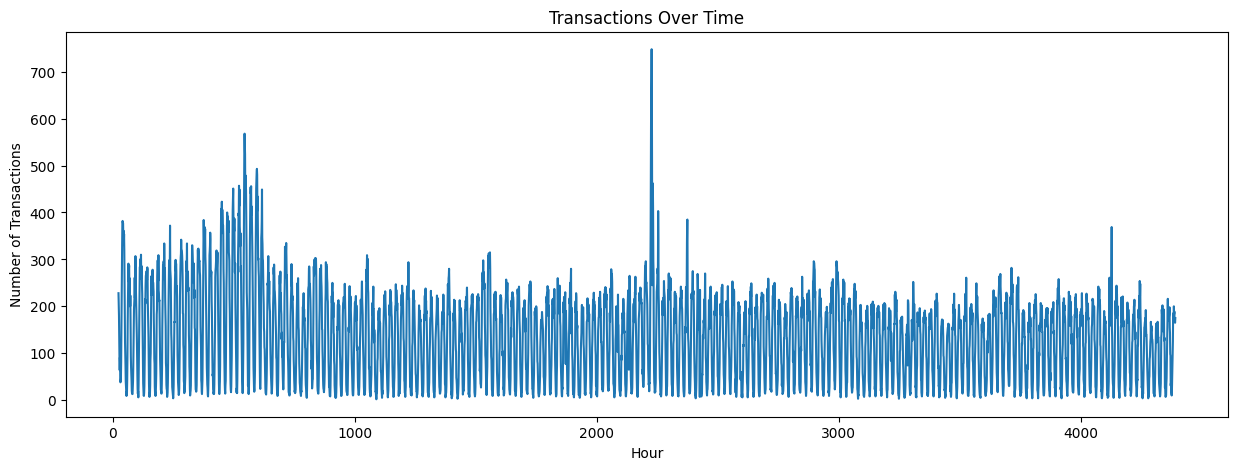

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(hourly_transactions.index, hourly_transactions.values)

plt.xlabel("Hour")
plt.ylabel("Number of Transactions")
plt.title("Transactions Over Time")

plt.show()

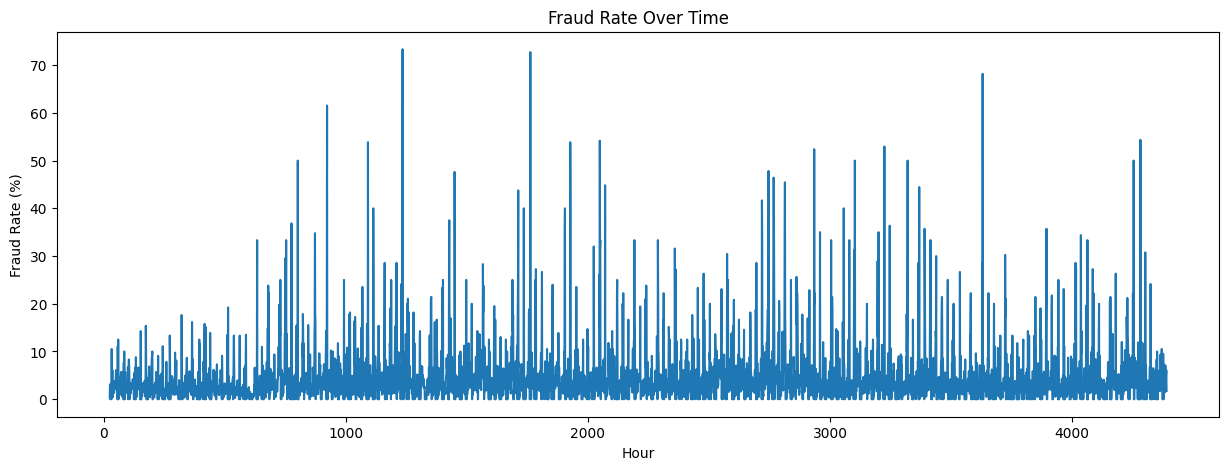

In [ ]:
hourly_fraud = transactions.groupby('hour')['isFraud'].mean() * 100

plt.figure(figsize=(15,5))

plt.plot(hourly_fraud.index, hourly_fraud.values)

plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate Over Time")

plt.show()

In [ ]:
unique_cards = transactions['card1'].nunique()

print("Unique card1 entities:", unique_cards)
print("Total transactions:", len(transactions))

Unique card1 entities: 13553
Total transactions: 590540


In [ ]:
transactions_per_card = transactions['card1'].value_counts()

print("Transactions per card:")
print(transactions_per_card.describe())

Transactions per card:
count    13553.000000
mean        43.572641
std        329.084462
min          1.000000
25%          1.000000
50%          4.000000
75%         14.000000
max      14932.000000
Name: count, dtype: float64


In [ ]:
transactions_per_card.head(20)

,count
card1,
7919,14932
9500,14162
15885,10361
17188,10344
15066,7945
12695,7091
12544,6773
6019,6771
2803,6141


In [ ]:
card_stats = transactions.groupby('card1')['isFraud'].agg(
    transactions='count',
    fraud_count='sum',
    fraud_rate='mean'
)

card_stats['fraud_rate'] = card_stats['fraud_rate'] * 100

card_stats.sort_values('fraud_rate', ascending=False).head(20)

,transactions,fraud_count,fraud_rate
card1,,,
18336,1,1,100.0
18318,1,1,100.0
11655,2,2,100.0
11795,1,1,100.0
12039,1,1,100.0
12095,1,1,100.0
4688,1,1,100.0
6975,1,1,100.0
6981,1,1,100.0


In [ ]:
card_stats_10 = card_stats[card_stats['transactions'] >= 10]

print("Entities with at least 10 transactions:", len(card_stats_10))

card_stats_10.sort_values('fraud_rate', ascending=False).head(20)

Entities with at least 10 transactions: 4298


,transactions,fraud_count,fraud_rate
card1,,,
3342,10,10,100.000000
12473,47,46,97.872340
11716,17,16,94.117647
2675,10,9,90.000000
11331,11,9,81.818182
1469,10,8,80.000000
5853,30,23,76.666667
12422,12,9,75.000000
8801,15,11,73.333333


In [ ]:
print("Top 20 most active card entities:")

print(
    transactions['card1']
    .value_counts()
    .head(20)
)

Top 20 most active card entities:
card1
7919     14932
9500     14162
15885    10361
17188    10344
15066     7945
12695     7091
12544     6773
6019      6771
2803      6141
7585      5334
10616     5172
12839     5129
3154      4614
2616      4410
18132     4209
9633      4158
15497     3977
16132     3929
2884      3873
16075     3748
Name: count, dtype: int64


In [ ]:
top_cards = transactions['card1'].value_counts().head(20).index

top_card_data = transactions[
    transactions['card1'].isin(top_cards)
]

top_card_summary = top_card_data.groupby('card1').agg(
    transactions=('TransactionID', 'count'),
    fraud_count=('isFraud', 'sum'),
    fraud_rate=('isFraud', 'mean'),
    total_amount=('TransactionAmt', 'sum'),
    average_amount=('TransactionAmt', 'mean')
)

top_card_summary['fraud_rate'] *= 100

top_card_summary.sort_values('transactions', ascending=False)

,transactions,fraud_count,fraud_rate,total_amount,average_amount
card1,,,,,
7919,14932,112,0.750067,1511265.490,101.209851
9500,14162,528,3.728287,1638516.765,115.698119
15885,10361,444,4.285301,408796.300,39.455294
17188,10344,278,2.687548,1340913.978,129.632055
15066,7945,313,3.939585,1667348.383,209.861345
12695,7091,201,2.834579,1000856.681,141.144645
12544,6773,146,2.155618,737973.752,108.958180
6019,6771,294,4.342047,1526463.291,225.441337
2803,6141,73,1.188731,876218.813,142.683409


In [ ]:
transactions['window_10m'] = (
    transactions['TransactionDT'] // 600
).astype(int)

print(transactions[['TransactionDT', 'window_10m']].head(20))

    TransactionDT  window_10m
0           86400         144
1           86401         144
2           86469         144
3           86499         144
4           86506         144
5           86510         144
6           86522         144
7           86529         144
8           86535         144
9           86536         144
10          86549         144
11          86555         144
12          86564         144
13          86585         144
14          86596         144
15          86618         144
16          86620         144
17          86668         144
18          86725         144
19          86730         144


In [ ]:
window_stats = transactions.groupby('window_10m').agg(
    transaction_count=('TransactionID', 'count'),
    fraud_count=('isFraud', 'sum'),
    total_amount=('TransactionAmt', 'sum'),
    average_amount=('TransactionAmt', 'mean')
)

window_stats['fraud_rate'] = (
    window_stats['fraud_count'] /
    window_stats['transaction_count']
) * 100

window_stats.head()

,transaction_count,fraud_count,total_amount,average_amount,fraud_rate
window_10m,,,,,
144,32,0,2860.412,89.387875,0.0
145,30,0,6137.036,204.567867,0.0
146,42,0,6010.031,143.095976,0.0
147,40,0,10994.956,274.873900,0.0
148,36,0,5293.046,147.029056,0.0


In [ ]:
window_stats.sort_values(
    'fraud_rate',
    ascending=False
).head(20)

,transaction_count,fraud_count,total_amount,average_amount,fraud_rate
window_10m,,,,,
10574,5,5,699.000,139.800,100.0
17037,4,4,334.612,83.653,100.0
4807,1,1,40.000,40.000,100.0
11431,1,1,100.000,100.000,100.0
7407,6,6,391.602,65.267,100.0
7123,1,1,59.000,59.000,100.0
7097,1,1,30.000,30.000,100.0
21066,2,2,337.950,168.975,100.0
7405,3,3,210.405,70.135,100.0


In [ ]:
large_windows = window_stats[
    window_stats['transaction_count'] >= 20
]

large_windows.sort_values(
    'fraud_rate',
    ascending=False
).head(20)

,transaction_count,fraud_count,total_amount,average_amount,fraud_rate
window_10m,,,,,
9680,20,11,1067.648,53.382400,55.000000
16879,21,10,2082.319,99.158048,47.619048
8592,23,9,2430.163,105.659261,39.130435
14201,35,13,3899.131,111.403743,37.142857
16880,22,8,1194.191,54.281409,36.363636
25010,33,12,3971.890,120.360303,36.363636
2187,25,8,2049.358,81.974320,32.000000
9246,22,7,1808.211,82.191409,31.818182
7485,38,12,4418.466,116.275421,31.578947


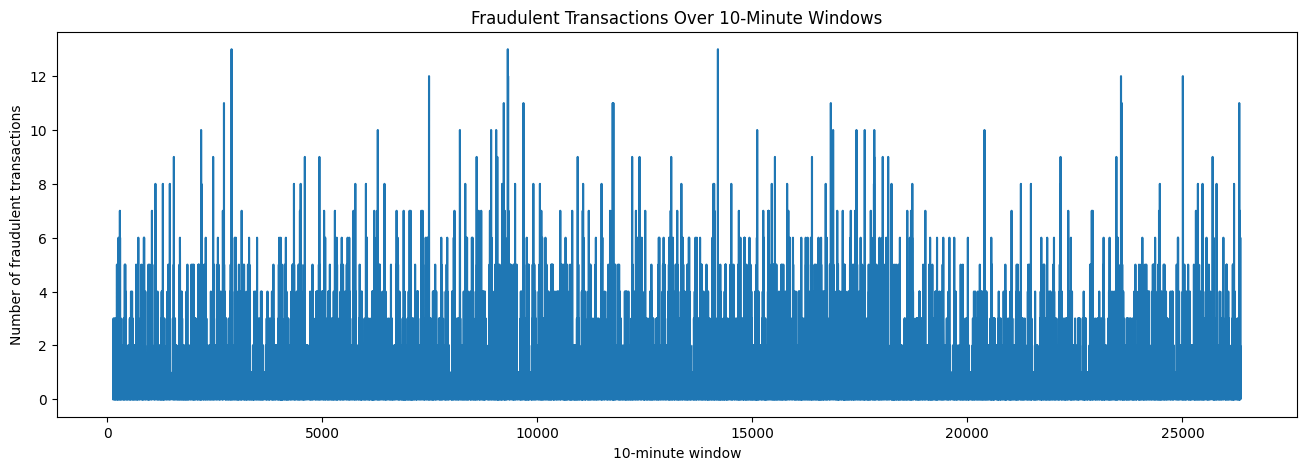

In [ ]:
plt.figure(figsize=(16, 5))

plt.plot(
    window_stats.index,
    window_stats['fraud_count']
)

plt.xlabel("10-minute window")
plt.ylabel("Number of fraudulent transactions")
plt.title("Fraudulent Transactions Over 10-Minute Windows")

plt.show()

In [ ]:
normal_windows = window_stats[
    window_stats['fraud_count'] == 0
]

fraud_windows = window_stats[
    window_stats['fraud_count'] > 0
]

print("Total 10-minute windows:", len(window_stats))
print("Windows with no fraud:", len(normal_windows))
print("Windows with fraud:", len(fraud_windows))

Total 10-minute windows: 25628
Windows with no fraud: 14905
Windows with fraud: 10723


In [ ]:
print("\nNORMAL WINDOWS")
print(normal_windows[['transaction_count', 'total_amount']].describe())

print("\nFRAUD WINDOWS")
print(fraud_windows[['transaction_count', 'total_amount']].describe())


NORMAL WINDOWS
       transaction_count  total_amount
count       14905.000000   14905.00000
mean           18.045354    2377.37839
std            15.210690    2445.05413
min             1.000000       4.10900
25%             4.000000     454.95000
50%            15.000000    1597.59900
75%            29.000000    3587.70200
max           126.000000   26346.21500

FRAUD WINDOWS
       transaction_count  total_amount
count       10723.000000  10723.000000
mean           29.989182   4131.691115
std            15.785829   2870.169895
min             1.000000      5.000000
25%            20.000000   2064.284000
50%            31.000000   3737.544000
75%            39.000000   5651.395000
max           134.000000  73040.678000


In [ ]:
median_transactions = window_stats['transaction_count'].median()

print("Median transactions per 10-minute window:", median_transactions)

Median transactions per 10-minute window: 23.0


In [ ]:
mean_transactions = window_stats['transaction_count'].mean()

print("Average transactions per 10-minute window:", mean_transactions)

Average transactions per 10-minute window: 23.042765724988293


In [ ]:
window_stats['velocity_ratio'] = (
    window_stats['transaction_count'] /
    median_transactions
)

window_stats[['transaction_count', 'velocity_ratio']].head(20)

,transaction_count,velocity_ratio
window_10m,,
144,32,1.391304
145,30,1.304348
146,42,1.826087
147,40,1.739130
148,36,1.565217
149,48,2.086957
150,40,1.739130
151,34,1.478261
152,33,1.434783


In [ ]:
identity = pd.read_csv('/content/train_identity.csv')

print("Identity rows:", len(identity))
print("Identity columns:", len(identity.columns))

Identity rows: 144233
Identity columns: 41


In [ ]:
identity.columns.tolist()

['TransactionID',
 'id_01',
 'id_02',
 'id_03',
 'id_04',
 'id_05',
 'id_06',
 'id_07',
 'id_08',
 'id_09',
 'id_10',
 'id_11',
 'id_12',
 'id_13',
 'id_14',
 'id_15',
 'id_16',
 'id_17',
 'id_18',
 'id_19',
 'id_20',
 'id_21',
 'id_22',
 'id_23',
 'id_24',
 'id_25',
 'id_26',
 'id_27',
 'id_28',
 'id_29',
 'id_30',
 'id_31',
 'id_32',
 'id_33',
 'id_34',
 'id_35',
 'id_36',
 'id_37',
 'id_38',
 'DeviceType',
 'DeviceInfo']

In [ ]:
print(identity.head())

   TransactionID  id_01     id_02  id_03  id_04  id_05  id_06  id_07  id_08  \
0        2987004    0.0   70787.0    NaN    NaN    NaN    NaN    NaN    NaN   
1        2987008   -5.0   98945.0    NaN    NaN    0.0   -5.0    NaN    NaN   
2        2987010   -5.0  191631.0    0.0    0.0    0.0    0.0    NaN    NaN   
3        2987011   -5.0  221832.0    NaN    NaN    0.0   -6.0    NaN    NaN   
4        2987016    0.0    7460.0    0.0    0.0    1.0    0.0    NaN    NaN   

   id_09  ...                id_31  id_32      id_33           id_34  id_35  \
0    NaN  ...  samsung browser 6.2   32.0  2220x1080  match_status:2      T   
1    NaN  ...   mobile safari 11.0   32.0   1334x750  match_status:1      T   
2    0.0  ...          chrome 62.0    NaN        NaN             NaN      F   
3    NaN  ...          chrome 62.0    NaN        NaN             NaN      F   
4    0.0  ...          chrome 62.0   24.0   1280x800  match_status:2      T   

  id_36 id_37  id_38  DeviceType                  

In [ ]:
identity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  object 
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  object 
 16  id_16          129340 non-null  object 
 17  id_17          139369 non-nul

In [ ]:
data = transactions.merge(
    identity,
    on='TransactionID',
    how='left'
)

print("Original transaction rows:", len(transactions))
print("Merged rows:", len(data))
print("Merged columns:", len(data.columns))

Original transaction rows: 590540
Merged rows: 590540
Merged columns: 436


In [ ]:
# Show all identity-related columns

identity_columns = [
    col for col in data.columns
    if col.startswith('id_')
]

print("Number of identity columns:", len(identity_columns))

print("\nIdentity columns:")
for col in identity_columns:
    print(col)

Number of identity columns: 38

Identity columns:
id_01
id_02
id_03
id_04
id_05
id_06
id_07
id_08
id_09
id_10
id_11
id_12
id_13
id_14
id_15
id_16
id_17
id_18
id_19
id_20
id_21
id_22
id_23
id_24
id_25
id_26
id_27
id_28
id_29
id_30
id_31
id_32
id_33
id_34
id_35
id_36
id_37
id_38


In [ ]:
device_columns = [
    col for col in data.columns
    if 'device' in col.lower()
]

print("Device-related columns:")

for col in device_columns:
    print(col)

Device-related columns:
DeviceType
DeviceInfo


In [ ]:
for col in device_columns:
    print("\n", col)
    print("Non-missing:", data[col].notna().sum())
    print("Missing:", data[col].isna().sum())
    print("Unique:", data[col].nunique())


 DeviceType
Non-missing: 140810
Missing: 449730
Unique: 2

 DeviceInfo
Non-missing: 118666
Missing: 471874
Unique: 1786


In [ ]:
for col in device_columns:
    print("\n====================")
    print(col)
    print("====================")
    print(data[col].value_counts(dropna=False).head(15))


DeviceType
DeviceType
NaN        449730
desktop     85165
mobile      55645
Name: count, dtype: int64

DeviceInfo
DeviceInfo
NaN                            471874
Windows                         47722
iOS Device                      19782
MacOS                           12573
Trident/7.0                      7440
rv:11.0                          1901
rv:57.0                           962
SM-J700M Build/MMB29K             549
SM-G610M Build/MMB29K             461
SM-G531H Build/LMY48B             410
rv:59.0                           362
SM-G935F Build/NRD90M             334
SM-G955U Build/NRD90M             328
SM-G532M Build/MMB29T             316
ALE-L23 Build/HuaweiALE-L23       312
Name: count, dtype: int64


In [ ]:
device_card_counts = (
    data.dropna(subset=['DeviceInfo'])
    .groupby('DeviceInfo')['card1']
    .nunique()
    .sort_values(ascending=False)
)

print("Devices connected to the most unique card entities:")

print(device_card_counts.head(20))

Devices connected to the most unique card entities:
DeviceInfo
Windows                          4846
iOS Device                       3104
MacOS                            2287
Trident/7.0                      1868
rv:11.0                           702
rv:57.0                           422
SM-G930V Build/NRD90M             167
SM-G950U Build/NRD90M             164
SM-G955U Build/NRD90M             163
SAMSUNG                           157
rv:59.0                           157
rv:58.0                           146
rv:52.0                           140
SM-N950U Build/NMF26X             133
rv:48.0                           102
SM-G935V Build/NRD90M              91
SM-G935F Build/NRD90M              80
SM-G950F Build/NRD90M              75
rv:56.0                            75
SAMSUNG SM-G950U Build/NRD90M      74
Name: card1, dtype: int64


In [ ]:
device_stats = (
    data.dropna(subset=['DeviceInfo'])
    .groupby('DeviceInfo')
    .agg(
        transactions=('TransactionID', 'count'),
        unique_cards=('card1', 'nunique'),
        fraud_count=('isFraud', 'sum')
    )
)

device_stats['fraud_rate'] = (
    device_stats['fraud_count'] /
    device_stats['transactions']
) * 100

device_stats.sort_values(
    'unique_cards',
    ascending=False
).head(20)

,transactions,unique_cards,fraud_count,fraud_rate
DeviceInfo,,,,
Windows,47722,4846,3121,6.539961
iOS Device,19782,3104,1240,6.268325
MacOS,12573,2287,278,2.211087
Trident/7.0,7440,1868,96,1.290323
rv:11.0,1901,702,76,3.997896
rv:57.0,962,422,103,10.706861
SM-G930V Build/NRD90M,274,167,0,0.000000
SM-G950U Build/NRD90M,290,164,16,5.517241
SM-G955U Build/NRD90M,328,163,33,10.060976


In [ ]:
device_stats_20 = device_stats[
    device_stats['transactions'] >= 20
]

print(
    "Devices with at least 20 transactions:",
    len(device_stats_20)
)

device_stats_20.sort_values(
    'fraud_rate',
    ascending=False
).head(20)

Devices with at least 20 transactions: 311


,transactions,unique_cards,fraud_count,fraud_rate
DeviceInfo,,,,
VS5012 Build/NRD90M,34,20,34,100.000000
SM-N920A Build/MMB29K,21,15,21,100.000000
Z835 Build/NMF26V,25,11,25,100.000000
hi6210sft Build/MRA58K,190,10,180,94.736842
LG-D320 Build/KOT49I.V10a,71,35,61,85.915493
TA-1039 Build/NMF26F,32,13,27,84.375000
SM-A300H Build/LRX22G,203,52,169,83.251232
VS425PP Build/LMY47V,28,20,23,82.142857
SM-A510M Build/MMB29K,56,21,45,80.357143


In [ ]:
device_card_map = (
    data.groupby('DeviceInfo')['card1']
    .nunique()
)

data['device_unique_cards'] = (
    data['DeviceInfo'].map(device_card_map)
)

print(
    data[
        ['DeviceInfo', 'card1', 'device_unique_cards']
    ].head(20)
)

                       DeviceInfo  card1  device_unique_cards
0                             NaN  13926                  NaN
1                             NaN   2755                  NaN
2                             NaN   4663                  NaN
3                             NaN  18132                  NaN
4   SAMSUNG SM-G892A Build/NRD90M   4497                  7.0
5                             NaN   5937                  NaN
6                             NaN  12308                  NaN
7                             NaN  12695                  NaN
8                      iOS Device   2803               3104.0
9                             NaN  17399                  NaN
10                        Windows  16496               4846.0
11                            NaN   4461                  NaN
12                            NaN   3786                  NaN
13                            NaN  12866                  NaN
14                            NaN  11839                  NaN
15      

In [ ]:
data['device_unique_cards'] = (
    data['device_unique_cards']
    .fillna(0)
)

print(
    data['device_unique_cards'].describe()
)

count    590540.000000
mean        572.477267
std        1431.815104
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        4846.000000
Name: device_unique_cards, dtype: float64


In [ ]:
card_window_counts = (
    data.groupby(['card1', 'window_10m'])
    .size()
    .reset_index(name='card_transactions_10m')
)

print(card_window_counts.head(20))

    card1  window_10m  card_transactions_10m
0    1000        9645                      1
1    1001        1527                      1
2    1001        5840                      1
3    1001        8784                      1
4    1004        1404                      1
5    1004        1703                      1
6    1004       16804                      1
7    1004       22588                      1
8    1004       22589                      1
9    1005        2021                      1
10   1006        3575                      1
11   1006        9805                      1
12   1006       19114                      1
13   1007        1417                      1
14   1007        9418                      1
15   1008        9741                      1
16   1008       12068                      1
17   1008       24270                      1
18   1009         590                      1
19   1009        1543                      1


In [ ]:
data = data.merge(
    card_window_counts,
    on=['card1', 'window_10m'],
    how='left'
)

print(
    data[
        ['card1', 'window_10m', 'card_transactions_10m']
    ].head(20)
)

    card1  window_10m  card_transactions_10m
0   13926         144                      1
1    2755         144                      1
2    4663         144                      2
3   18132         144                      1
4    4497         144                      1
5    5937         144                      1
6   12308         144                      1
7   12695         144                      1
8    2803         144                      1
9   17399         144                      1
10  16496         144                      1
11   4461         144                      1
12   3786         144                      1
13  12866         144                      1
14  11839         144                      1
15   7055         144                      1
16   1790         144                      1
17  11492         144                      1
18   4663         144                      2
19   7005         144                      1


In [ ]:
card_amount_stats = (
    data.groupby('card1')['TransactionAmt']
    .agg(
        card_avg_amount='mean',
        card_median_amount='median'
    )
)

data = data.merge(
    card_amount_stats,
    on='card1',
    how='left'
)

print(
    data[
        [
            'card1',
            'TransactionAmt',
            'card_avg_amount',
            'card_median_amount'
        ]
    ].head(20)
)

    card1  TransactionAmt  card_avg_amount  card_median_amount
0   13926          68.500       351.931163            150.0000
1    2755          29.000       234.292753            113.0000
2    4663          59.000        97.015542             59.0000
3   18132          50.000       123.416340             59.9500
4    4497          50.000        96.972222            108.9500
5    5937          49.000       134.071429            117.0000
6   12308         159.000       101.880097             59.0000
7   12695         422.500       141.144645             83.9700
8    2803          15.000       142.683409             77.0000
9   17399         117.000       122.020491             60.0000
10  16496          75.887        58.849000             58.6985
11   4461          16.495        39.989204             28.7865
12   3786          50.000        87.765919             59.0000
13  12866          40.000       109.526806             59.0000
14  11839          10.500       129.685690             

In [ ]:
feature_columns = [
    'TransactionAmt',
    'card_transactions_10m',
    'device_unique_cards',
    'amount_vs_card_avg'
]

print(data[feature_columns].describe())

KeyError: "['amount_vs_card_avg'] not in index"

In [ ]:
# Recreate the amount anomaly feature

data['amount_vs_card_avg'] = (
    data['TransactionAmt'] / data['card_avg_amount']
)

print("Feature created successfully!")

print(
    data[
        [
            'TransactionAmt',
            'card_avg_amount',
            'amount_vs_card_avg'
        ]
    ].head(20)
)

Feature created successfully!
    TransactionAmt  card_avg_amount  amount_vs_card_avg
0           68.500       351.931163            0.194640
1           29.000       234.292753            0.123777
2           59.000        97.015542            0.608150
3           50.000       123.416340            0.405133
4           50.000        96.972222            0.515612
5           49.000       134.071429            0.365477
6          159.000       101.880097            1.560658
7          422.500       141.144645            2.993383
8           15.000       142.683409            0.105128
9          117.000       122.020491            0.958855
10          75.887        58.849000            1.289521
11          16.495        39.989204            0.412486
12          50.000        87.765919            0.569697
13          40.000       109.526806            0.365207
14          10.500       129.685690            0.080965
15          57.950        66.762000            0.868009
16          30.000

In [ ]:
feature_columns = [
    'TransactionAmt',
    'card_transactions_10m',
    'device_unique_cards',
    'amount_vs_card_avg'
]

print(data[feature_columns].describe())

       TransactionAmt  card_transactions_10m  device_unique_cards  \
count   590540.000000          590540.000000        590540.000000   
mean       135.027176               1.366058           572.477267   
std        239.162522               1.438941          1431.815104   
min          0.251000               1.000000             0.000000   
25%         43.321000               1.000000             0.000000   
50%         68.769000               1.000000             0.000000   
75%        125.000000               1.000000             0.000000   
max      31937.391000              50.000000          4846.000000   

       amount_vs_card_avg  
count       590540.000000  
mean             1.000000  
std              1.366219  
min              0.002787  
25%              0.382915  
50%              0.636604  
75%              1.100988  
max            114.123913  


In [ ]:
# Remove the features we don't want to use
# We will rebuild the useful ones correctly.

columns_to_remove = [
    'device_unique_cards',
    'amount_vs_card_avg'
]

for col in columns_to_remove:
    if col in data.columns:
        data = data.drop(columns=[col])

print("Removed outdated features.")
print("Current columns:", len(data.columns))

Removed outdated features.
Current columns: 439


In [ ]:
# ==========================================
# BUILD OUR 10-MINUTE FRAUD DETECTOR DATASET
# ==========================================

window_features = data.groupby('window_10m').agg(

    # How much activity happened?
    transaction_count=('TransactionID', 'count'),

    # Money involved
    total_amount=('TransactionAmt', 'sum'),
    average_amount=('TransactionAmt', 'mean'),

    # How many different card entities?
    unique_cards=('card1', 'nunique'),

    # How many transactions came from repeat entities?
    unique_products=('ProductCD', 'nunique')
).reset_index()

print("Number of 10-minute windows:", len(window_features))

print("\nFirst 10 windows:")
print(window_features.head(10))

Number of 10-minute windows: 25628

First 10 windows:
   window_10m  transaction_count  total_amount  average_amount  unique_cards  \
0         144                 32      2860.412       89.387875            31   
1         145                 30      6137.036      204.567867            28   
2         146                 42      6010.031      143.095976            36   
3         147                 40     10994.956      274.873900            34   
4         148                 36      5293.046      147.029056            33   
5         149                 48     13638.943      284.144646            46   
6         150                 40      6013.353      150.333825            36   
7         151                 34      2861.488       84.161412            34   
8         152                 33      6093.439      184.649667            31   
9         153                 35      6013.999      171.828543            28   

   unique_products  
0                3  
1                4  
2 

In [ ]:
# Calculate the normal transaction volume

normal_transaction_volume = (
    window_features['transaction_count'].median()
)

print(
    "Normal transactions per 10-minute window:",
    normal_transaction_volume
)

# Calculate velocity ratio

window_features['velocity_ratio'] = (
    window_features['transaction_count'] /
    normal_transaction_volume
)

print("\nVelocity examples:")
print(
    window_features[
        ['transaction_count', 'velocity_ratio']
    ].head(20)
)

Normal transactions per 10-minute window: 23.0

Velocity examples:
    transaction_count  velocity_ratio
0                  32        1.391304
1                  30        1.304348
2                  42        1.826087
3                  40        1.739130
4                  36        1.565217
5                  48        2.086957
6                  40        1.739130
7                  34        1.478261
8                  33        1.434783
9                  35        1.521739
10                 36        1.565217
11                 23        1.000000
12                 38        1.652174
13                 29        1.260870
14                 25        1.086957
15                 28        1.217391
16                 34        1.478261
17                 26        1.130435
18                 18        0.782609
19                 24        1.043478


In [ ]:
window_features['amount_ratio'] = (
    window_features['total_amount'] /
    window_features['total_amount'].median()
)

print(
    window_features[
        [
            'total_amount',
            'amount_ratio'
        ]
    ].describe()
)

       total_amount  amount_ratio
count  25628.000000  25628.000000
mean    3111.399592      1.208991
std     2769.906522      1.076298
min        4.109000      0.001597
25%      804.357750      0.312548
50%     2573.550500      1.000000
75%     4611.334500      1.791818
max    73040.678000     28.381288


In [ ]:
fraud_outcomes = data.groupby('window_10m').agg(
    fraud_count=('isFraud', 'sum'),
    fraud_rate=('isFraud', 'mean')
).reset_index()

window_features = window_features.merge(
    fraud_outcomes,
    on='window_10m',
    how='left'
)

window_features['fraud_rate'] *= 100

print(window_features.head(20))

    window_10m  transaction_count  total_amount  average_amount  unique_cards  \
0          144                 32      2860.412       89.387875            31   
1          145                 30      6137.036      204.567867            28   
2          146                 42      6010.031      143.095976            36   
3          147                 40     10994.956      274.873900            34   
4          148                 36      5293.046      147.029056            33   
5          149                 48     13638.943      284.144646            46   
6          150                 40      6013.353      150.333825            36   
7          151                 34      2861.488       84.161412            34   
8          152                 33      6093.439      184.649667            31   
9          153                 35      6013.999      171.828543            28   
10         154                 36      3599.778       99.993833            32   
11         155              

In [ ]:
# ==========================================
# DEFINE OUR FIRST FRAUD-SPIKE LABEL
# ==========================================

window_features['fraud_spike'] = (
    (window_features['transaction_count'] >= 20) &
    (window_features['fraud_rate'] >= 20)
).astype(int)

print("Fraud spike distribution:")
print(
    window_features['fraud_spike'].value_counts()
)

print("\nPercentage of windows classified as spikes:")
print(
    window_features['fraud_spike'].mean() * 100
)

Fraud spike distribution:
fraud_spike
0    25499
1      129
Name: count, dtype: int64

Percentage of windows classified as spikes:
0.5033557046979865


In [ ]:
# ==========================================
# TEST DIFFERENT FRAUD-SPIKE DEFINITIONS
# ==========================================

thresholds = [10, 15, 20, 25, 30]

print("Fraud spike sensitivity analysis")
print("--------------------------------")

for threshold in thresholds:

    spike_count = (
        (window_features['transaction_count'] >= 20) &
        (window_features['fraud_rate'] >= threshold)
    ).sum()

    spike_percentage = (
        spike_count / len(window_features) * 100
    )

    print(
        f"{threshold}% fraud threshold:"
        f" {spike_count} spikes"
        f" ({spike_percentage:.3f}% of windows)"
    )

Fraud spike sensitivity analysis
--------------------------------
10% fraud threshold: 1089 spikes (4.249% of windows)
15% fraud threshold: 337 spikes (1.315% of windows)
20% fraud threshold: 129 spikes (0.503% of windows)
25% fraud threshold: 50 spikes (0.195% of windows)
30% fraud threshold: 11 spikes (0.043% of windows)


In [ ]:
# Show the characteristics of our 129 current spike windows

spike_windows = window_features[
    window_features['fraud_spike'] == 1
]

print("Number of spike windows:", len(spike_windows))

print("\nSpike window statistics:")
print(
    spike_windows[
        [
            'transaction_count',
            'total_amount',
            'average_amount',
            'unique_cards',
            'fraud_count',
            'fraud_rate'
        ]
    ].describe()
)

Number of spike windows: 129

Spike window statistics:
       transaction_count  total_amount  average_amount  unique_cards  \
count         129.000000    129.000000      129.000000    129.000000   
mean           30.852713   3901.186465      124.534432     25.914729   
std             8.227337   1915.709514       47.292681      7.436219   
min            20.000000   1028.806000       42.866917     10.000000   
25%            24.000000   2490.161000       89.570950     21.000000   
50%            30.000000   3677.660000      115.294848     25.000000   
75%            37.000000   4895.320000      158.814208     30.000000   
max            58.000000  11335.705000      291.941136     49.000000   

       fraud_count  fraud_rate  
count    129.00000  129.000000  
mean       7.51938   24.692498  
std        2.10320    5.117678  
min        4.00000   20.000000  
25%        6.00000   21.428571  
50%        7.00000   23.255814  
75%        9.00000   26.315789  
max       13.00000   55.000000  

In [ ]:
# ==========================================
# FINAL PROTOTYPE SPIKE LABEL
# ==========================================

window_features['fraud_spike'] = (
    (window_features['transaction_count'] >= 20) &
    (window_features['fraud_rate'] >= 15)
).astype(int)

print("Final spike definition:")
print("At least 20 transactions AND at least 15% fraud")

print("\nSpike distribution:")
print(window_features['fraud_spike'].value_counts())

print("\nSpike percentage:")
print(window_features['fraud_spike'].mean() * 100)

Final spike definition:
At least 20 transactions AND at least 15% fraud

Spike distribution:
fraud_spike
0    25291
1      337
Name: count, dtype: int64

Spike percentage:
1.3149680037459028


In [ ]:
# ==========================================
# SORT WINDOWS IN TIME ORDER
# ==========================================

window_features = window_features.sort_values(
    'window_10m'
).reset_index(drop=True)

print(window_features[
    ['window_10m', 'transaction_count', 'fraud_rate', 'fraud_spike']
].head(20))

    window_10m  transaction_count  fraud_rate  fraud_spike
0          144                 32    0.000000            0
1          145                 30    0.000000            0
2          146                 42    0.000000            0
3          147                 40    0.000000            0
4          148                 36    0.000000            0
5          149                 48    2.083333            0
6          150                 40    7.500000            0
7          151                 34    2.941176            0
8          152                 33    0.000000            0
9          153                 35    2.857143            0
10         154                 36    2.777778            0
11         155                 23    0.000000            0
12         156                 38    0.000000            0
13         157                 29    0.000000            0
14         158                 25    0.000000            0
15         159                 28    0.000000           

In [ ]:
# ==========================================
# HISTORICAL ACTIVITY BASELINES
# ==========================================

# Previous 1 hour
window_features['avg_transactions_prev_1h'] = (
    window_features['transaction_count']
    .shift(1)
    .rolling(6)
    .mean()
)

# Previous 3 hours
window_features['avg_transactions_prev_3h'] = (
    window_features['transaction_count']
    .shift(1)
    .rolling(18)
    .mean()
)

# Previous 24 hours
window_features['avg_transactions_prev_24h'] = (
    window_features['transaction_count']
    .shift(1)
    .rolling(144)
    .mean()
)

print(
    window_features[
        [
            'transaction_count',
            'avg_transactions_prev_1h',
            'avg_transactions_prev_3h',
            'avg_transactions_prev_24h'
        ]
    ].head(160)
)

     transaction_count  avg_transactions_prev_1h  avg_transactions_prev_3h  \
0                   32                       NaN                       NaN   
1                   30                       NaN                       NaN   
2                   42                       NaN                       NaN   
3                   40                       NaN                       NaN   
4                   36                       NaN                       NaN   
..                 ...                       ...                       ...   
155                 40                 43.166667                 51.777778   
156                 19                 41.000000                 51.111111   
157                 22                 36.000000                 49.166667   
158                 35                 33.500000                 47.388889   
159                 33                 32.666667                 46.555556   

     avg_transactions_prev_24h  
0                          NaN

In [ ]:
# ==========================================
# RECENT VELOCITY RATIOS
# ==========================================

window_features['velocity_vs_1h'] = (
    window_features['transaction_count'] /
    window_features['avg_transactions_prev_1h']
)

window_features['velocity_vs_3h'] = (
    window_features['transaction_count'] /
    window_features['avg_transactions_prev_3h']
)

window_features['velocity_vs_24h'] = (
    window_features['transaction_count'] /
    window_features['avg_transactions_prev_24h']
)

print(
    window_features[
        [
            'transaction_count',
            'velocity_vs_1h',
            'velocity_vs_3h',
            'velocity_vs_24h'
        ]
    ].tail(20)
)

       transaction_count  velocity_vs_1h  velocity_vs_3h  velocity_vs_24h
25608                 27        0.915254        0.888483         1.343469
25609                 31        1.075145        1.025735         1.541969
25610                 23        0.797688        0.759633         1.142069
25611                 24        0.832370        0.800000         1.191724
25612                 33        1.144509        1.097967         1.647712
25613                 32        1.136095        1.062731         1.599445
25614                 32        1.129412        1.051095         1.595568
25615                 27        0.925714        0.891743         1.349063
25616                 28        0.982456        0.945591         1.398058
25617                 39        1.329545        1.322034         1.949323
25618                 26        0.816754        0.884688         1.294158
25619                 27        0.880435        0.918715         1.346727
25620                 27        0.9050

In [ ]:
# ==========================================
# HISTORICAL MONEY-FLOW BASELINES
# ==========================================

window_features['avg_amount_prev_1h'] = (
    window_features['total_amount']
    .shift(1)
    .rolling(6)
    .mean()
)

window_features['avg_amount_prev_3h'] = (
    window_features['total_amount']
    .shift(1)
    .rolling(18)
    .mean()
)

window_features['avg_amount_prev_24h'] = (
    window_features['total_amount']
    .shift(1)
    .rolling(144)
    .mean()
)

# Money velocity

window_features['amount_velocity_1h'] = (
    window_features['total_amount'] /
    window_features['avg_amount_prev_1h']
)

window_features['amount_velocity_3h'] = (
    window_features['total_amount'] /
    window_features['avg_amount_prev_3h']
)

window_features['amount_velocity_24h'] = (
    window_features['total_amount'] /
    window_features['avg_amount_prev_24h']
)

print(
    window_features[
        [
            'total_amount',
            'amount_velocity_1h',
            'amount_velocity_3h',
            'amount_velocity_24h'
        ]
    ].tail(20)
)

       total_amount  amount_velocity_1h  amount_velocity_3h  \
25608      3653.657            0.579269            0.587875   
25609      7159.366            1.204210            1.148598   
25610      7458.292            1.318177            1.167673   
25611      4427.714            0.721009            0.665194   
25612      5920.116            0.995754            0.881658   
25613      3169.567            0.505850            0.471671   
25614      7576.721            1.430078            1.141519   
25615      4049.136            0.680303            0.606607   
25616      3850.446            0.708637            0.590427   
25617      5129.869            1.061583            0.832234   
25618      3460.792            0.699247            0.605073   
25619      4112.459            0.905943            0.729993   
25620      5375.000            1.144452            0.989140   
25621      5251.414            1.212905            0.970874   
25622      6577.635            1.452018            1.26

In [ ]:
# ==========================================
# COMPARE NORMAL VS SPIKE WINDOWS
# ==========================================

normal = window_features[
    window_features['fraud_spike'] == 0
]

spikes = window_features[
    window_features['fraud_spike'] == 1
]

comparison = pd.DataFrame({
    'Normal windows': normal[
        [
            'transaction_count',
            'total_amount',
            'velocity_vs_1h',
            'velocity_vs_3h',
            'velocity_vs_24h',
            'amount_velocity_1h',
            'amount_velocity_24h'
        ]
    ].median(),

    'Spike windows': spikes[
        [
            'transaction_count',
            'total_amount',
            'velocity_vs_1h',
            'velocity_vs_3h',
            'velocity_vs_24h',
            'amount_velocity_1h',
            'amount_velocity_24h'
        ]
    ].median()
})

print(comparison)

                     Normal windows  Spike windows
transaction_count         23.000000      31.000000
total_amount            2553.859000    3650.872000
velocity_vs_1h             0.982759       1.054054
velocity_vs_3h             0.959016       1.011527
velocity_vs_24h            1.039175       1.424232
amount_velocity_1h         0.917701       0.964310
amount_velocity_24h        0.876346       1.249235


In [ ]:
# ==========================================
# BUILD CLEAN ML DATASET
# ==========================================

model_features = [
    'transaction_count',
    'total_amount',
    'average_amount',
    'unique_cards',
    'velocity_vs_1h',
    'velocity_vs_3h',
    'velocity_vs_24h',
    'amount_velocity_1h',
    'amount_velocity_3h',
    'amount_velocity_24h'
]

target = 'fraud_spike'

ml_data = window_features[
    model_features + [target]
].copy()

print("Original windows:", len(ml_data))

# Remove rows where historical baselines don't exist
ml_data = ml_data.dropna()

print("Usable windows:", len(ml_data))

print("\nClass distribution:")
print(ml_data[target].value_counts())

print("\nSpike percentage:")
print(ml_data[target].mean() * 100)

Original windows: 25628
Usable windows: 25484

Class distribution:
fraud_spike
0    25147
1      337
Name: count, dtype: int64

Spike percentage:
1.322398367603202


In [ ]:
# ==========================================
# CHECK SPIKES ACROSS TIME
# ==========================================

n = len(ml_data)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train_data = ml_data.iloc[:train_end]
validation_data = ml_data.iloc[train_end:validation_end]
test_data = ml_data.iloc[validation_end:]

print("TRAIN")
print("Rows:", len(train_data))
print("Spikes:", train_data[target].sum())
print("Spike rate:", train_data[target].mean() * 100)

print("\nVALIDATION")
print("Rows:", len(validation_data))
print("Spikes:", validation_data[target].sum())
print("Spike rate:", validation_data[target].mean() * 100)

print("\nTEST")
print("Rows:", len(test_data))
print("Spikes:", test_data[target].sum())
print("Spike rate:", test_data[target].mean() * 100)

TRAIN
Rows: 17838
Spikes: 249
Spike rate: 1.3958964009418096

VALIDATION
Rows: 3823
Spikes: 39
Spike rate: 1.0201412503269682

TEST
Rows: 3823
Spikes: 49
Spike rate: 1.2817159298979859


In [ ]:
# ==========================================
# FIRST FRAUD-SPIKE MODEL
# LOGISTIC REGRESSION
# ==========================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)
import numpy as np

# Features the model is allowed to see
model_features = [
    'transaction_count',
    'total_amount',
    'average_amount',
    'unique_cards',
    'velocity_vs_1h',
    'velocity_vs_3h',
    'velocity_vs_24h',
    'amount_velocity_1h',
    'amount_velocity_3h',
    'amount_velocity_24h'
]

# Split features and target
X_train = train_data[model_features]
y_train = train_data['fraud_spike']

X_val = validation_data[model_features]
y_val = validation_data['fraud_spike']

X_test = test_data[model_features]
y_test = test_data['fraud_spike']

# Replace infinite values if any exist
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_val = X_val.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Use training medians to fill missing values
train_medians = X_train.median()

X_train = X_train.fillna(train_medians)
X_val = X_val.fillna(train_medians)
X_test = X_test.fillna(train_medians)

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
# ==========================================
# GET SPIKE PROBABILITIES
# ==========================================

val_probabilities = model.predict_proba(
    X_val_scaled
)[:, 1]

test_probabilities = model.predict_proba(
    X_test_scaled
)[:, 1]

print("First 20 validation probabilities:")
print(val_probabilities[:20])

First 20 validation probabilities:
[0.22600064 0.18313543 0.34751611 0.13094532 0.10136463 0.14025196
 0.09872996 0.12354877 0.10568567 0.10312716 0.11061832 0.12934551
 0.13689239 0.14496254 0.18891031 0.1728099  0.15635479 0.19586569
 0.29424457 0.33167437]


In [ ]:
# ==========================================
# TEST DIFFERENT ALERT THRESHOLDS
# ==========================================

thresholds = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

print(
    f"{'Threshold':<12}"
    f"{'Precision':<12}"
    f"{'Recall':<12}"
    f"{'F1':<12}"
)

print("-" * 48)

for threshold in thresholds:

    predictions = (
        val_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    print(
        f"{threshold:<12.2f}"
        f"{precision:<12.3f}"
        f"{recall:<12.3f}"
        f"{f1:<12.3f}"
    )

Threshold   Precision   Recall      F1          
------------------------------------------------
0.10        0.010       1.000       0.020       
0.20        0.012       1.000       0.024       
0.30        0.015       1.000       0.030       
0.40        0.018       0.974       0.035       
0.50        0.021       0.897       0.042       
0.60        0.023       0.667       0.045       
0.70        0.020       0.333       0.037       
0.80        0.024       0.154       0.042       
0.90        0.036       0.051       0.042       


In [ ]:
# ==========================================
# PRECISION-RECALL AUC
# ==========================================

val_pr_auc = average_precision_score(
    y_val,
    val_probabilities
)

test_pr_auc = average_precision_score(
    y_test,
    test_probabilities
)

print("Validation PR-AUC:", val_pr_auc)
print("Test PR-AUC:", test_pr_auc)

Validation PR-AUC: 0.02875119661065777
Test PR-AUC: 0.027053534373052187


In [ ]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

threshold = 0.50

val_predictions = (
    val_probabilities >= threshold
).astype(int)

cm = confusion_matrix(
    y_val,
    val_predictions
)

print("Confusion matrix:")
print(cm)

print("\nDetailed report:")
print(
    classification_report(
        y_val,
        val_predictions,
        target_names=[
            'Normal',
            'Fraud Spike'
        ],
        zero_division=0
    )
)

Confusion matrix:
[[2178 1606]
 [   4   35]]

Detailed report:
              precision    recall  f1-score   support

      Normal       1.00      0.58      0.73      3784
 Fraud Spike       0.02      0.90      0.04        39

    accuracy                           0.58      3823
   macro avg       0.51      0.74      0.39      3823
weighted avg       0.99      0.58      0.72      3823



In [ ]:
# ==========================================
# FEATURE IMPORTANCE
# ==========================================

feature_importance = pd.DataFrame({
    'feature': model_features,
    'coefficient': model.coef_[0]
})

feature_importance['absolute_effect'] = (
    feature_importance['coefficient'].abs()
)

feature_importance = feature_importance.sort_values(
    'absolute_effect',
    ascending=False
)

print(feature_importance)

               feature  coefficient  absolute_effect
6      velocity_vs_24h     2.697274         2.697274
3         unique_cards    -2.414732         2.414732
9  amount_velocity_24h    -1.042154         1.042154
0    transaction_count     0.784076         0.784076
1         total_amount     0.766127         0.766127
5       velocity_vs_3h    -0.594391         0.594391
4       velocity_vs_1h     0.276519         0.276519
7   amount_velocity_1h     0.134962         0.134962
8   amount_velocity_3h     0.090304         0.090304
2       average_amount    -0.040724         0.040724


In [ ]:
# ==========================================
# STEP 68: COMPARE FEATURES
# ==========================================

comparison_features = [
    'transaction_count',
    'total_amount',
    'average_amount',
    'unique_cards',
    'velocity_vs_1h',
    'velocity_vs_3h',
    'velocity_vs_24h',
    'amount_velocity_1h',
    'amount_velocity_3h',
    'amount_velocity_24h'
]

print("NORMAL WINDOWS")
print(
    train_data[train_data['fraud_spike'] == 0][comparison_features]
    .median()
)

print("\nSPIKE WINDOWS")
print(
    train_data[train_data['fraud_spike'] == 1][comparison_features]
    .median()
)

NORMAL WINDOWS
transaction_count        24.000000
total_amount           2678.987000
average_amount          115.363933
unique_cards             21.000000
velocity_vs_1h            0.984375
velocity_vs_3h            0.955340
velocity_vs_24h           1.030546
amount_velocity_1h        0.924140
amount_velocity_3h        0.888624
amount_velocity_24h       0.877405
dtype: float64

SPIKE WINDOWS
transaction_count        31.000000
total_amount           3766.008000
average_amount          118.091000
unique_cards             27.000000
velocity_vs_1h            1.058824
velocity_vs_3h            1.014925
velocity_vs_24h           1.413497
amount_velocity_1h        0.974312
amount_velocity_3h        0.884229
amount_velocity_24h       1.230406
dtype: float64


In [ ]:
# ==========================================
# STEP 69: UNIQUE CARDS ANALYSIS
# ==========================================

print("NORMAL WINDOWS")
print(
    train_data[
        train_data['fraud_spike'] == 0
    ]['unique_cards'].describe()
)

print("\nSPIKE WINDOWS")
print(
    train_data[
        train_data['fraud_spike'] == 1
    ]['unique_cards'].describe()
)

NORMAL WINDOWS
count    17589.000000
mean        21.315424
std         15.043762
min          1.000000
25%          7.000000
50%         21.000000
75%         32.000000
max        104.000000
Name: unique_cards, dtype: float64

SPIKE WINDOWS
count    249.000000
mean      27.510040
std        7.881743
min       10.000000
25%       22.000000
50%       27.000000
75%       32.000000
max       63.000000
Name: unique_cards, dtype: float64


In [ ]:
print("\nMedian unique cards:")
print(
    "Normal:",
    train_data[
        train_data['fraud_spike'] == 0
    ]['unique_cards'].median()
)

print(
    "Spike:",
    train_data[
        train_data['fraud_spike'] == 1
    ]['unique_cards'].median()
)


Median unique cards:
Normal: 21.0
Spike: 27.0


In [ ]:
# ==========================================
# STEP 71: RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
# ==========================================
# RANDOM FOREST PROBABILITIES
# ==========================================

rf_val_probabilities = rf_model.predict_proba(
    X_val
)[:, 1]

rf_test_probabilities = rf_model.predict_proba(
    X_test
)[:, 1]

print("First 20 Random Forest probabilities:")
print(rf_val_probabilities[:20])

First 20 Random Forest probabilities:
[0.         0.         0.         0.         0.         0.
 0.00083015 0.         0.         0.         0.         0.
 0.         0.         0.00277293 0.         0.00228813 0.00477887
 0.37357637 0.34367311]


In [ ]:
# ==========================================
# RANDOM FOREST THRESHOLD ANALYSIS
# ==========================================

thresholds = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

print(
    f"{'Threshold':<12}"
    f"{'Precision':<12}"
    f"{'Recall':<12}"
    f"{'F1':<12}"
)

print("-" * 48)

for threshold in thresholds:

    predictions = (
        rf_val_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    print(
        f"{threshold:<12.2f}"
        f"{precision:<12.3f}"
        f"{recall:<12.3f}"
        f"{f1:<12.3f}"
    )

Threshold   Precision   Recall      F1          
------------------------------------------------
0.10        0.019       1.000       0.038       
0.20        0.020       1.000       0.039       
0.30        0.020       1.000       0.040       
0.40        0.022       0.923       0.042       
0.50        0.026       0.795       0.050       
0.60        0.029       0.487       0.054       
0.70        0.023       0.026       0.024       
0.80        0.000       0.000       0.000       
0.90        0.000       0.000       0.000       


In [ ]:
# ==========================================
# RANDOM FOREST PR-AUC
# ==========================================

rf_val_pr_auc = average_precision_score(
    y_val,
    rf_val_probabilities
)

rf_test_pr_auc = average_precision_score(
    y_test,
    rf_test_probabilities
)

print("Random Forest Validation PR-AUC:", rf_val_pr_auc)
print("Random Forest Test PR-AUC:", rf_test_pr_auc)

Random Forest Validation PR-AUC: 0.02983635423257297
Random Forest Test PR-AUC: 0.06427069348610988


In [ ]:
# ==========================================
# STEP 74: CHECK VALIDATION VS TEST
# ==========================================

print("VALIDATION FEATURE MEDIANS")
print(
    validation_data[
        model_features
    ].median()
)

print("\nTEST FEATURE MEDIANS")
print(
    test_data[
        model_features
    ].median()
)

print("\nVALIDATION SPIKE RATE")
print(y_val.mean())

print("\nTEST SPIKE RATE")
print(y_test.mean())

VALIDATION FEATURE MEDIANS
transaction_count        21.000000
total_amount           2269.080000
average_amount          115.627529
unique_cards             19.000000
velocity_vs_1h            0.979592
velocity_vs_3h            0.964880
velocity_vs_24h           1.065949
amount_velocity_1h        0.914518
amount_velocity_3h        0.880136
amount_velocity_24h       0.879769
dtype: float64

TEST FEATURE MEDIANS
transaction_count        21.000000
total_amount           2334.851000
average_amount          112.294408
unique_cards             19.000000
velocity_vs_1h            0.978261
velocity_vs_3h            0.967071
velocity_vs_24h           1.067985
amount_velocity_1h        0.889845
amount_velocity_3h        0.853641
amount_velocity_24h       0.885052
dtype: float64

VALIDATION SPIKE RATE
0.010201412503269683

TEST SPIKE RATE
0.012817159298979858


In [ ]:
# ==========================================
# CHECK RANDOM FOREST PROBABILITY DISTRIBUTION
# ==========================================

print("Validation probability statistics:")
print(pd.Series(rf_val_probabilities).describe())

print("\nTest probability statistics:")
print(pd.Series(rf_test_probabilities).describe())

Validation probability statistics:
count    3823.000000
mean        0.277800
std         0.272394
min         0.000000
25%         0.000000
50%         0.303054
75%         0.551582
max         0.832000
dtype: float64

Test probability statistics:
count    3823.000000
mean        0.286660
std         0.272530
min         0.000000
25%         0.000000
50%         0.347559
75%         0.552632
max         0.879259
dtype: float64


In [ ]:
# ==========================================
# STEP 75: TOP TEST ALERTS
# ==========================================

test_results = test_data[
    model_features + ['fraud_spike']
].copy()

test_results['risk_score'] = rf_test_probabilities

top_alerts = test_results.sort_values(
    'risk_score',
    ascending=False
).head(20)

print(
    top_alerts[
        [
            'risk_score',
            'fraud_spike',
            'transaction_count',
            'total_amount',
            'unique_cards',
            'velocity_vs_24h',
            'amount_velocity_24h'
        ]
    ]
)

       risk_score  fraud_spike  transaction_count  total_amount  unique_cards  \
22293    0.879259            0                 21      1522.072            17   
23415    0.825105            1                 22      1139.682            14   
23417    0.810523            1                 20      1379.959            18   
23263    0.799714            0                 30      2341.531            26   
23266    0.796397            0                 31      2145.998            24   
22418    0.791052            0                 30      2136.338            27   
24672    0.780215            0                 23      1329.921            17   
22420    0.780098            0                 30      2334.851            28   
22703    0.779824            0                 22      1392.481            19   
24675    0.770418            1                 29      1596.542            23   
22426    0.760995            0                 25      2538.091            21   
22006    0.760080           

In [ ]:
# ==========================================
# STEP 76: PRECISION AT TOP-K ALERTS
# ==========================================

def precision_at_top_k(y_true, probabilities, percentage):

    n = len(probabilities)

    k = max(1, int(n * percentage))

    # Highest-risk windows first
    ranking = np.argsort(probabilities)[::-1]

    top_k_indices = ranking[:k]

    top_k_actual = np.array(y_true)[top_k_indices]

    precision = top_k_actual.mean()

    return k, precision, top_k_actual.sum()


percentages = [0.01, 0.02, 0.05, 0.10]

print("VALIDATION")
print("=" * 60)

for percentage in percentages:

    k, precision, spikes_found = precision_at_top_k(
        y_val,
        rf_val_probabilities,
        percentage
    )

    print(
        f"Top {percentage*100:.0f}%: "
        f"{k} alerts | "
        f"{spikes_found} real spikes | "
        f"Precision = {precision:.3f}"
    )


print("\nTEST")
print("=" * 60)

for percentage in percentages:

    k, precision, spikes_found = precision_at_top_k(
        y_test,
        rf_test_probabilities,
        percentage
    )

    print(
        f"Top {percentage*100:.0f}%: "
        f"{k} alerts | "
        f"{spikes_found} real spikes | "
        f"Precision = {precision:.3f}"
    )

VALIDATION
Top 1%: 38 alerts | 1 real spikes | Precision = 0.026
Top 2%: 76 alerts | 2 real spikes | Precision = 0.026
Top 5%: 191 alerts | 6 real spikes | Precision = 0.031
Top 10%: 382 alerts | 10 real spikes | Precision = 0.026

TEST
Top 1%: 38 alerts | 4 real spikes | Precision = 0.105
Top 2%: 76 alerts | 4 real spikes | Precision = 0.053
Top 5%: 191 alerts | 6 real spikes | Precision = 0.031
Top 10%: 382 alerts | 15 real spikes | Precision = 0.039


In [ ]:
# ==========================================
# STEP 77: SIMPLE VELOCITY BASELINE
# ==========================================

baseline_thresholds = [
    1.1,
    1.2,
    1.3,
    1.4,
    1.5,
    1.75,
    2.0
]

print(
    f"{'Threshold':<12}"
    f"{'Precision':<12}"
    f"{'Recall':<12}"
    f"{'F1':<12}"
)

print("-" * 48)

for threshold in baseline_thresholds:

    predictions = (
        validation_data['velocity_vs_24h'] >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    print(
        f"{threshold:<12.2f}"
        f"{precision:<12.3f}"
        f"{recall:<12.3f}"
        f"{f1:<12.3f}"
    )

Threshold   Precision   Recall      F1          
------------------------------------------------
1.10        0.019       0.923       0.038       
1.20        0.020       0.846       0.039       
1.30        0.020       0.718       0.038       
1.40        0.022       0.667       0.042       
1.50        0.018       0.436       0.034       
1.75        0.024       0.282       0.045       
2.00        0.024       0.103       0.039       


In [ ]:
# ==========================================
# STEP 79: ACCELERATION FEATURES
# ==========================================

for df in [train_data, validation_data, test_data]:

    df['velocity_acceleration_1h_24h'] = (
        df['velocity_vs_1h'] /
        (df['velocity_vs_24h'] + 0.001)
    )

    df['amount_acceleration_1h_24h'] = (
        df['amount_velocity_1h'] /
        (df['amount_velocity_24h'] + 0.001)
    )

    df['volume_per_card'] = (
        df['transaction_count'] /
        (df['unique_cards'] + 1)
    )

print("New features created.")

print(
    train_data[
        [
            'velocity_acceleration_1h_24h',
            'amount_acceleration_1h_24h',
            'volume_per_card'
        ]
    ].describe()
)

New features created.
       velocity_acceleration_1h_24h  amount_acceleration_1h_24h  \
count                  17838.000000                17838.000000   
mean                       2.488314                    3.077420   
std                        3.149907                    4.677840   
min                        0.292706                    0.212813   
25%                        0.641862                    0.636175   
50%                        0.921586                    1.012667   
75%                        2.919145                    3.451944   
max                       23.952260                   72.008544   

       volume_per_card  
count     17838.000000  
mean          1.005077  
std           0.185087  
min           0.500000  
25%           0.933333  
50%           1.038099  
75%           1.117647  
max           3.000000  


/tmp/ipykernel_1012/2728060618.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['velocity_acceleration_1h_24h'] = (
/tmp/ipykernel_1012/2728060618.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['amount_acceleration_1h_24h'] = (
/tmp/ipykernel_1012/2728060618.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

In [ ]:
# ==========================================
# STEP 80: CLEAN DATAFRAME COPIES
# ==========================================

train_data = train_data.copy()
validation_data = validation_data.copy()
test_data = test_data.copy()

print("Dataframes safely copied.")

Dataframes safely copied.


In [ ]:
# ==========================================
# STEP 81: RECREATE ACCELERATION FEATURES
# ==========================================

for df in [train_data, validation_data, test_data]:

    df.loc[:, 'velocity_acceleration_1h_24h'] = (
        df['velocity_vs_1h'] /
        (df['velocity_vs_24h'] + 0.001)
    )

    df.loc[:, 'amount_acceleration_1h_24h'] = (
        df['amount_velocity_1h'] /
        (df['amount_velocity_24h'] + 0.001)
    )

    df.loc[:, 'volume_per_card'] = (
        df['transaction_count'] /
        (df['unique_cards'] + 1)
    )

print("Acceleration features recreated successfully.")

Acceleration features recreated successfully.


In [ ]:
# ==========================================
# STEP 82: TRAIN RANDOM FOREST WITH
# ACCELERATION FEATURES
# ==========================================

new_features = [
    'transaction_count',
    'total_amount',
    'average_amount',
    'unique_cards',

    'velocity_vs_1h',
    'velocity_vs_3h',
    'velocity_vs_24h',

    'amount_velocity_1h',
    'amount_velocity_3h',
    'amount_velocity_24h',

    'velocity_acceleration_1h_24h',
    'amount_acceleration_1h_24h',
    'volume_per_card'
]

X_train_new = train_data[new_features]
y_train_new = train_data['fraud_spike']

X_val_new = validation_data[new_features]
y_val_new = validation_data['fraud_spike']

X_test_new = test_data[new_features]
y_test_new = test_data['fraud_spike']

print("Features:", len(new_features))
print("Training rows:", len(X_train_new))
print("Validation rows:", len(X_val_new))
print("Test rows:", len(X_test_new))

Features: 13
Training rows: 17838
Validation rows: 3823
Test rows: 3823


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_new = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_new.fit(X_train_new, y_train_new)

print("New Random Forest trained.")

New Random Forest trained.


In [ ]:
rf_new_val_probabilities = rf_new.predict_proba(
    X_val_new
)[:, 1]

rf_new_test_probabilities = rf_new.predict_proba(
    X_test_new
)[:, 1]

print("Validation probabilities generated.")
print("Test probabilities generated.")

Validation probabilities generated.
Test probabilities generated.


In [ ]:
from sklearn.metrics import average_precision_score

new_val_pr_auc = average_precision_score(
    y_val_new,
    rf_new_val_probabilities
)

new_test_pr_auc = average_precision_score(
    y_test_new,
    rf_new_test_probabilities
)

print("NEW RANDOM FOREST")
print("-------------------------")
print("Validation PR-AUC:", new_val_pr_auc)
print("Test PR-AUC:", new_test_pr_auc)

NEW RANDOM FOREST
-------------------------
Validation PR-AUC: 0.036228592661302586
Test PR-AUC: 0.054179253239748426


In [ ]:
print("NEW RANDOM FOREST - TOP-K TEST")
print("=" * 60)

for percentage in [0.01, 0.02, 0.05, 0.10]:

    k, precision, spikes_found = precision_at_top_k(
        y_test_new,
        rf_new_test_probabilities,
        percentage
    )

    print(
        f"Top {percentage*100:.0f}%: "
        f"{k} alerts | "
        f"{spikes_found} real spikes | "
        f"Precision = {precision:.3f}"
    )

NEW RANDOM FOREST - TOP-K TEST
Top 1%: 38 alerts | 3 real spikes | Precision = 0.079
Top 2%: 76 alerts | 4 real spikes | Precision = 0.053
Top 5%: 191 alerts | 9 real spikes | Precision = 0.047
Top 10%: 382 alerts | 18 real spikes | Precision = 0.047


In [ ]:
# ==========================================
# STEP 84: CARD CONCENTRATION FEATURES
# ==========================================

def add_card_concentration_features(df):

    df = df.copy()

    # How many transactions are happening per unique card
    df['transactions_per_card'] = (
        df['transaction_count'] /
        (df['unique_cards'] + 1)
    )

    # How different is the number of transactions
    # from the number of unique cards?
    df['card_concentration'] = (
        1 -
        (df['unique_cards'] / df['transaction_count'])
    )

    # Avoid impossible values
    df['card_concentration'] = (
        df['card_concentration']
        .clip(lower=0, upper=1)
    )

    return df


train_data = add_card_concentration_features(train_data)
validation_data = add_card_concentration_features(validation_data)
test_data = add_card_concentration_features(test_data)

print("Card concentration features created.")

print(
    train_data[
        [
            'transactions_per_card',
            'card_concentration'
        ]
    ].describe()
)

Card concentration features created.
       transactions_per_card  card_concentration
count           17838.000000        17838.000000
mean                1.005077            0.093607
std                 0.185087            0.088680
min                 0.500000            0.000000
25%                 0.933333            0.000000
50%                 1.038099            0.085714
75%                 1.117647            0.145833
max                 3.000000            0.833333


In [ ]:
# ==========================================
# STEP 85: COMPARE CARD CONCENTRATION
# ==========================================

normal = train_data[
    train_data['fraud_spike'] == 0
]

spikes = train_data[
    train_data['fraud_spike'] == 1
]

print("NORMAL WINDOWS")
print("==============")

print(
    normal[
        [
            'transactions_per_card',
            'card_concentration'
        ]
    ].median()
)

print("\nSPIKE WINDOWS")
print("=============")

print(
    spikes[
        [
            'transactions_per_card',
            'card_concentration'
        ]
    ].median()
)

NORMAL WINDOWS
transactions_per_card    1.035714
card_concentration       0.083333
dtype: float64

SPIKE WINDOWS
transactions_per_card    1.121212
card_concentration       0.136364
dtype: float64


In [ ]:
# ==========================================
# STEP 86: SHARPER CARD BEHAVIOUR FEATURES
# ==========================================

for df in [train_data, validation_data, test_data]:

    df.loc[:, 'repeat_transaction_ratio'] = (
        (df['transaction_count'] - df['unique_cards'])
        / df['transaction_count'].clip(lower=1)
    )

    df.loc[:, 'repeat_transactions'] = (
        df['transaction_count'] - df['unique_cards']
    )

print("Sharper card behaviour features created.")

print("\nNORMAL WINDOWS")
print(
    train_data[train_data['fraud_spike'] == 0][
        [
            'repeat_transaction_ratio',
            'repeat_transactions'
        ]
    ].median()
)

print("\nSPIKE WINDOWS")
print(
    train_data[train_data['fraud_spike'] == 1][
        [
            'repeat_transaction_ratio',
            'repeat_transactions'
        ]
    ].median()
)

Sharper card behaviour features created.

NORMAL WINDOWS
repeat_transaction_ratio    0.083333
repeat_transactions         2.000000
dtype: float64

SPIKE WINDOWS
repeat_transaction_ratio    0.136364
repeat_transactions         5.000000
dtype: float64


In [ ]:
print("Transaction columns:")
print(transactions.columns.tolist())

print("\nFirst TransactionDT values:")
print(transactions['TransactionDT'].head())

print("\nLast TransactionDT values:")
print(transactions['TransactionDT'].tail())

Transaction columns:
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V

In [ ]:
# ==========================================
# STEP 88A: CHECK HOW WINDOWS ARE DEFINED
# ==========================================

print("TransactionDT range:")
print("Minimum:", transactions['TransactionDT'].min())
print("Maximum:", transactions['TransactionDT'].max())

print("\nTransactionDT difference:")
print(
    transactions['TransactionDT'].diff().describe()
)

TransactionDT range:
Minimum: 86400
Maximum: 15811131

TransactionDT difference:
count    590539.000000
mean         26.627760
std          59.299088
min           0.000000
25%           5.000000
50%          13.000000
75%          29.000000
max        4138.000000
Name: TransactionDT, dtype: float64


In [ ]:
# ==========================================
# STEP 88B: AMOUNT CONCENTRATION FEATURES
# ==========================================

import numpy as np
import pandas as pd

# Make a copy so we don't modify the original data
tx = transactions.copy()

# Assign every transaction to a 10-minute window
tx['window_10m'] = tx['TransactionDT'] // 600

# ------------------------------------------------
# 1. Basic amount statistics for each window
# ------------------------------------------------

amount_features = tx.groupby('window_10m')['TransactionAmt'].agg(
    total_amount='sum',
    max_amount='max',
    median_transaction_amount='median'
)

# ------------------------------------------------
# 2. Largest transaction as % of window amount
# ------------------------------------------------

amount_features['largest_amount_share'] = (
    amount_features['max_amount'] /
    amount_features['total_amount'].clip(lower=0.001)
)

# ------------------------------------------------
# 3. Top 3 transactions as % of window amount
# ------------------------------------------------

top3_amounts = (
    tx.groupby('window_10m')['TransactionAmt']
    .apply(lambda x: x.nlargest(3).sum())
)

amount_features['top3_amount_share'] = (
    top3_amounts /
    amount_features['total_amount'].clip(lower=0.001)
)

# ------------------------------------------------
# 4. Number of unusually large transactions
#
# "Unusually large" = more than 3x the
# median transaction amount in that window
# ------------------------------------------------

tx['amount_ratio_to_window_median'] = (
    tx['TransactionAmt'] /
    tx.groupby('window_10m')['TransactionAmt']
      .transform('median').clip(lower=0.001)
)

large_amount_counts = (
    tx.groupby('window_10m')['amount_ratio_to_window_median']
    .apply(lambda x: (x >= 3).sum())
)

amount_features['large_transaction_count'] = large_amount_counts

# ------------------------------------------------
# 5. Percentage of transactions that are large
# ------------------------------------------------

transaction_counts = (
    tx.groupby('window_10m')['TransactionAmt']
    .count()
)

amount_features['large_transaction_ratio'] = (
    amount_features['large_transaction_count'] /
    transaction_counts.clip(lower=1)
)

print("Amount concentration features created.")

print("\nSample:")
print(amount_features.head())

print("\nSummary:")
print(
    amount_features[
        [
            'largest_amount_share',
            'top3_amount_share',
            'large_transaction_count',
            'large_transaction_ratio'
        ]
    ].describe()
)

Amount concentration features created.

Sample:
            total_amount  max_amount  median_transaction_amount  \
window_10m                                                        
144             2860.412      422.50                    50.0000   
145             6137.036     2454.00                    67.4185   
146             6010.031      554.00                    94.4750   
147            10994.956     3000.00                    89.9750   
148             5293.046      973.95                    71.4750   

            largest_amount_share  top3_amount_share  large_transaction_count  \
window_10m                                                                     
144                     0.147706           0.339948                        6   
145                     0.399867           0.607459                        6   
146                     0.092179           0.253909                        7   
147                     0.272852           0.613818                        5   
14

In [ ]:
# ==========================================
# STEP 89: DO AMOUNT FEATURES DIFFERENTIATE
# NORMAL VS SPIKE WINDOWS?
# ==========================================

# Get the spike labels from our existing window data
labels = window_features[['fraud_spike']].copy()

# Join the new amount features
amount_analysis = labels.join(
    amount_features,
    how='inner'
)

print("NORMAL WINDOWS")
print("==============")

print(
    amount_analysis[
        amount_analysis['fraud_spike'] == 0
    ][
        [
            'largest_amount_share',
            'top3_amount_share',
            'large_transaction_count',
            'large_transaction_ratio'
        ]
    ].median()
)

print("\nSPIKE WINDOWS")
print("=============")

print(
    amount_analysis[
        amount_analysis['fraud_spike'] == 1
    ][
        [
            'largest_amount_share',
            'top3_amount_share',
            'large_transaction_count',
            'large_transaction_ratio'
        ]
    ].median()
)

NORMAL WINDOWS
largest_amount_share       0.232538
top3_amount_share          0.473140
large_transaction_count    2.000000
large_transaction_ratio    0.111111
dtype: float64

SPIKE WINDOWS
largest_amount_share       0.232824
top3_amount_share          0.468916
large_transaction_count    3.000000
large_transaction_ratio    0.127016
dtype: float64


In [ ]:
# ==========================================
# STEP 90: INTRA-WINDOW BURST FEATURES
# ==========================================

tx = transactions.copy()

# 10-minute window
tx['window_10m'] = tx['TransactionDT'] // 600

# Position inside the 10-minute window
tx['second_in_window'] = tx['TransactionDT'] % 600

# 1-minute bucket inside each 10-minute window
tx['minute_in_window'] = (
    tx['second_in_window'] // 60
)

# ------------------------------------------
# Count transactions in each minute
# ------------------------------------------

minute_counts = (
    tx.groupby(
        ['window_10m', 'minute_in_window']
    )
    .size()
)

# Busiest minute
max_1m = (
    minute_counts
    .groupby(level=0)
    .max()
)

# Average minute activity
mean_1m = (
    minute_counts
    .groupby(level=0)
    .mean()
)

# ------------------------------------------
# Build feature table
# ------------------------------------------

burst_features = pd.DataFrame(index=max_1m.index)

burst_features['max_1m_transactions'] = max_1m

burst_features['max_1m_share'] = (
    max_1m /
    tx.groupby('window_10m').size()
)

burst_features['burstiness_ratio'] = (
    max_1m /
    mean_1m.clip(lower=0.001)
)

# ------------------------------------------
# First 5 minutes vs last 5 minutes
# ------------------------------------------

first_half = (
    tx[tx['second_in_window'] < 300]
    .groupby('window_10m')
    .size()
)

last_half = (
    tx[tx['second_in_window'] >= 300]
    .groupby('window_10m')
    .size()
)

total_transactions = (
    tx.groupby('window_10m')
    .size()
)

burst_features['first_half_share'] = (
    first_half /
    total_transactions
)

burst_features['last_half_share'] = (
    last_half /
    total_transactions
)

print("Burst features created.")

print("\nSUMMARY")
print(
    burst_features.describe()
)

Burst features created.

SUMMARY
       max_1m_transactions  max_1m_share  burstiness_ratio  first_half_share  \
count         25628.000000  25628.000000      25628.000000      24511.000000   
mean              4.684759      0.283815          1.677103          0.522802   
std               2.746436      0.191884          0.430112          0.157260   
min               1.000000      0.105263          1.000000          0.047619   
25%               2.000000      0.178571          1.428571          0.428571   
50%               5.000000      0.214286          1.666667          0.500000   
75%               7.000000      0.300000          1.935484          0.588235   
max              22.000000      1.000000          4.000000          1.000000   

       last_half_share  
count     24500.000000  
mean          0.523004  
std           0.156910  
min           0.071429  
25%           0.428571  
50%           0.500000  
75%           0.588235  
max           1.000000  


In [ ]:
# ==========================================
# STEP 91: NORMAL VS SPIKE BURST BEHAVIOUR
# ==========================================

burst_analysis = window_features[
    ['fraud_spike']
].join(
    burst_features,
    how='inner'
)

print("NORMAL WINDOWS")
print("==============")

print(
    burst_analysis[
        burst_analysis['fraud_spike'] == 0
    ][
        [
            'max_1m_transactions',
            'max_1m_share',
            'burstiness_ratio',
            'first_half_share',
            'last_half_share'
        ]
    ].median()
)

print("\nSPIKE WINDOWS")
print("=============")

print(
    burst_analysis[
        burst_analysis['fraud_spike'] == 1
    ][
        [
            'max_1m_transactions',
            'max_1m_share',
            'burstiness_ratio',
            'first_half_share',
            'last_half_share'
        ]
    ].median()
)

NORMAL WINDOWS
max_1m_transactions    5.000000
max_1m_share           0.214286
burstiness_ratio       1.666667
first_half_share       0.500000
last_half_share        0.500000
dtype: float64

SPIKE WINDOWS
max_1m_transactions    5.000000
max_1m_share           0.206897
burstiness_ratio       1.666667
first_half_share       0.510658
last_half_share        0.500000
dtype: float64


In [ ]:
# ============================================================
# STEP 92A: CREATE 5-MINUTE EARLY-WARNING FEATURES
# ============================================================

tx = transactions.copy()

# Create the same 10-minute window used earlier
tx['window_10m'] = tx['TransactionDT'] // 600

# Find where each transaction sits inside its 10-minute window
tx['second_in_window'] = tx['TransactionDT'] % 600

# Keep ONLY the first 5 minutes
early_tx = tx[
    tx['second_in_window'] < 300
].copy()

print("Transactions in early-warning period:", len(early_tx))

# ------------------------------------------------------------
# Basic activity features from the first 5 minutes
# ------------------------------------------------------------

early_counts = (
    early_tx
    .groupby('window_10m')
    .agg(
        early_transaction_count=('TransactionID', 'count'),
        early_total_amount=('TransactionAmt', 'sum'),
        early_average_amount=('TransactionAmt', 'mean'),
        early_unique_cards=('card1', 'nunique'),
        early_fraud_count=('isFraud', 'sum')
    )
)

# ------------------------------------------------------------
# Fraud rate observed during first 5 minutes
# ------------------------------------------------------------

early_counts['early_fraud_rate'] = (
    early_counts['early_fraud_count']
    /
    early_counts['early_transaction_count']
)

# ------------------------------------------------------------
# Merge with the FINAL 10-minute spike label
# ------------------------------------------------------------

early_warning = early_counts.join(
    window_features[['fraud_spike']],
    how='inner'
)

print("\nEarly-warning dataset created.")

print("Rows:", len(early_warning))

print("\nClass distribution:")
print(
    early_warning['fraud_spike'].value_counts()
)

print("\nSpike percentage:")
print(
    early_warning['fraud_spike'].mean() * 100
)

print("\nFirst few rows:")
print(
    early_warning.head()
)

Transactions in early-warning period: 294979

Early-warning dataset created.
Rows: 23853

Class distribution:
fraud_spike
0    23533
1      320
Name: count, dtype: int64

Spike percentage:
1.3415503290990651

First few rows:
     early_transaction_count  early_total_amount  early_average_amount  \
144                       18            1399.832             77.768444   
145                       16            1776.137            111.008562   
146                       21            3319.690            158.080476   
147                       16            2501.108            156.319250   
148                       19            2303.326            121.227684   

     early_unique_cards  early_fraud_count  early_fraud_rate  fraud_spike  
144                  18                  0               0.0            0  
145                  16                  0               0.0            0  
146                  18                  0               0.0            0  
147                  14   

In [ ]:
# ============================================================
# STEP 92B: COMPARE EARLY-WARNING SIGNALS
# ============================================================

early_normal = early_warning[
    early_warning['fraud_spike'] == 0
]

early_spike = early_warning[
    early_warning['fraud_spike'] == 1
]

features_to_compare = [
    'early_transaction_count',
    'early_total_amount',
    'early_average_amount',
    'early_unique_cards',
    'early_fraud_rate'
]

print("EARLY ACTIVITY - EVENTUALLY NORMAL")
print("===================================")

print(
    early_normal[features_to_compare].median()
)

print("\nEARLY ACTIVITY - EVENTUALLY SPIKE")
print("==================================")

print(
    early_spike[features_to_compare].median()
)

EARLY ACTIVITY - EVENTUALLY NORMAL
early_transaction_count      12.00000
early_total_amount         1266.22600
early_average_amount        108.50975
early_unique_cards           11.00000
early_fraud_rate              0.00000
dtype: float64

EARLY ACTIVITY - EVENTUALLY SPIKE
early_transaction_count      13.000000
early_total_amount         1460.502500
early_average_amount        115.235625
early_unique_cards           12.000000
early_fraud_rate              0.000000
dtype: float64


In [ ]:
print(len(transactions))
print(transactions.columns[:10].tolist())

NameError: name 'transactions' is not defined

In [ ]:
import os

print(os.listdir('/content')[:50])

['.config', 'train_identity.csv', 'train_transaction.csv', 'sample_data']


In [ ]:
import pandas as pd
import gc

# Load ONLY the columns needed for our fraud-spike analysis
transaction_columns = [
    'TransactionID',
    'isFraud',
    'TransactionDT',
    'TransactionAmt',
    'card1'
]

transactions = pd.read_csv(
    '/content/train_transaction.csv',
    usecols=transaction_columns
)

print("Transactions loaded:", len(transactions))
print("Columns:", transactions.columns.tolist())

# Free temporary memory
gc.collect()

Transactions loaded: 590540
Columns: ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'card1']


0

In [ ]:
# ============================================================
# STEP 95: RECREATE 10-MINUTE FRAUD-SPIKE LABEL
# ============================================================

import numpy as np
import pandas as pd

print("Creating 10-minute windows...")

# Make a compact copy
tx = transactions[
    [
        'TransactionID',
        'isFraud',
        'TransactionDT',
        'TransactionAmt',
        'card1'
    ]
].copy()

# 10-minute window
tx['window_10m'] = (
    tx['TransactionDT'] // 600
)

# Aggregate each 10-minute window
window_features = (
    tx
    .groupby('window_10m')
    .agg(
        transaction_count=(
            'TransactionID',
            'count'
        ),

        total_amount=(
            'TransactionAmt',
            'sum'
        ),

        average_amount=(
            'TransactionAmt',
            'mean'
        ),

        unique_cards=(
            'card1',
            'nunique'
        ),

        fraud_count=(
            'isFraud',
            'sum'
        )
    )
)

# Fraud rate
window_features['fraud_rate'] = (
    window_features['fraud_count']
    /
    window_features['transaction_count']
    *
    100
)

# ------------------------------------------------------------
# OUR CURRENT SPIKE DEFINITION
#
# At least 20 transactions
# AND
# at least 20% fraud
# ------------------------------------------------------------

window_features['fraud_spike'] = (
    (
        window_features['transaction_count'] >= 20
    )
    &
    (
        window_features['fraud_rate'] >= 20
    )
).astype(int)

print("\n========================================")
print("10-MINUTE WINDOWS CREATED")
print("========================================")

print(
    "Total windows:",
    len(window_features)
)

print("\nClass distribution:")

print(
    window_features['fraud_spike'].value_counts()
)

print("\nSpike percentage:")

print(
    window_features['fraud_spike'].mean() * 100
)

Creating 10-minute windows...

10-MINUTE WINDOWS CREATED
Total windows: 25628

Class distribution:
fraud_spike
0    25499
1      129
Name: count, dtype: int64

Spike percentage:
0.5033557046979865


In [ ]:
# ============================================================
# STEP 96: MEMORY-SAFE EARLY-WARNING FEATURES
# ============================================================

print("Creating early-warning dataset...")

# ------------------------------------------------------------
# Work with the already-loaded compact dataset
# ------------------------------------------------------------

tx['second_in_window'] = (
    tx['TransactionDT'] % 600
)

# First 5 minutes only
early_tx = tx[
    tx['second_in_window'] < 300
].copy()

print(
    "Transactions in first 5 minutes:",
    len(early_tx)
)


# ------------------------------------------------------------
# Basic early-window features
# ------------------------------------------------------------

early_features = (
    early_tx
    .groupby('window_10m')
    .agg(
        early_transaction_count=(
            'TransactionID',
            'count'
        ),

        early_total_amount=(
            'TransactionAmt',
            'sum'
        ),

        early_average_amount=(
            'TransactionAmt',
            'mean'
        ),

        early_unique_cards=(
            'card1',
            'nunique'
        )
    )
)


# ------------------------------------------------------------
# Relative features
#
# Compare early activity with the typical activity of
# the dataset.
# ------------------------------------------------------------

# Overall average 5-minute transaction count
overall_5m_count = (
    early_features[
        'early_transaction_count'
    ].median()
)

# Overall median 5-minute amount
overall_5m_amount = (
    early_features[
        'early_total_amount'
    ].median()
)

early_features['count_vs_typical'] = (
    early_features[
        'early_transaction_count'
    ]
    /
    overall_5m_count
)

early_features['amount_vs_typical'] = (
    early_features[
        'early_total_amount'
    ]
    /
    overall_5m_amount
)

early_features['unique_card_ratio'] = (
    early_features[
        'early_unique_cards'
    ]
    /
    early_features[
        'early_transaction_count'
    ]
)


# ------------------------------------------------------------
# Add final spike label
# ------------------------------------------------------------

early_features = early_features.join(
    window_features[['fraud_spike']],
    how='inner'
)


print("\n========================================")
print("EARLY-WARNING DATASET")
print("========================================")

print(
    "Rows:",
    len(early_features)
)

print("\nClass distribution:")

print(
    early_features[
        'fraud_spike'
    ].value_counts()
)

print("\nSpike rate:")

print(
    early_features[
        'fraud_spike'
    ].mean() * 100
)

print("\nFeatures:")

print(
    early_features.columns.tolist()
)

Creating early-warning dataset...
Transactions in first 5 minutes: 294979

EARLY-WARNING DATASET
Rows: 24511

Class distribution:
fraud_spike
0    24382
1      129
Name: count, dtype: int64

Spike rate:
0.5262943168373384

Features:
['early_transaction_count', 'early_total_amount', 'early_average_amount', 'early_unique_cards', 'count_vs_typical', 'amount_vs_typical', 'unique_card_ratio', 'fraud_spike']


In [ ]:
# ============================================================
# STEP 97: EARLY SIGNAL COMPARISON
# ============================================================

features_to_compare = [
    'early_transaction_count',
    'early_total_amount',
    'early_average_amount',
    'early_unique_cards',
    'count_vs_typical',
    'amount_vs_typical',
    'unique_card_ratio'
]

normal = early_features[
    early_features['fraud_spike'] == 0
]

spikes = early_features[
    early_features['fraud_spike'] == 1
]

comparison = pd.DataFrame({
    'Normal': normal[
        features_to_compare
    ].median(),

    'Eventually Spike': spikes[
        features_to_compare
    ].median()
})

comparison['Difference %'] = (
    (
        comparison['Eventually Spike']
        -
        comparison['Normal']
    )
    /
    comparison['Normal'].replace(
        0,
        np.nan
    )
) * 100

print(comparison)

                              Normal  Eventually Spike  Difference %
early_transaction_count    11.000000         14.000000     27.272727
early_total_amount       1258.356500       1791.471000     42.365935
early_average_amount      108.628937        114.021100      4.963837
early_unique_cards         11.000000         13.000000     18.181818
count_vs_typical            0.916667          1.166667     27.272727
amount_vs_typical           0.997670          1.420343     42.365935
unique_card_ratio           1.000000          0.913043     -8.695652


In [ ]:
# ============================================================
# STEP 98: SHARPEN EARLY-WARNING BEHAVIOURAL FEATURES
# ============================================================

print("Creating sharper early-warning features...")

# Work only with the first 5 minutes
early = early_tx.copy()

# ------------------------------------------------------------
# 1. Transactions per card
# ------------------------------------------------------------

early_card_counts = (
    early
    .groupby('window_10m')['card1']
    .value_counts()
)

transactions_per_card = (
    early_card_counts
    .groupby(level=0)
    .mean()
    .rename('transactions_per_card')
)


# ------------------------------------------------------------
# 2. Amount concentration
# ------------------------------------------------------------

def amount_features(group):

    amounts = group['TransactionAmt'].sort_values(
        ascending=False
    )

    total = amounts.sum()

    if total == 0:
        return pd.Series({
            'max_amount': 0,
            'largest_amount_share': 0,
            'top3_amount_share': 0,
            'large_transaction_count': 0,
            'large_transaction_ratio': 0
        })

    median_amount = amounts.median()

    return pd.Series({
        'max_amount': amounts.iloc[0],

        'largest_amount_share':
            amounts.iloc[0] / total,

        'top3_amount_share':
            amounts.head(3).sum() / total,

        'large_transaction_count':
            (amounts > median_amount * 2).sum(),

        'large_transaction_ratio':
            (amounts > median_amount * 2).mean()
    })


amount_features_df = (
    early
    .groupby('window_10m')
    .apply(
        amount_features,
        include_groups=False
    )
)


# ------------------------------------------------------------
# 3. 1-minute burst features
# ------------------------------------------------------------

early['minute_in_early'] = (
    early['second_in_window'] // 60
)

minute_counts = (
    early
    .groupby(
        ['window_10m', 'minute_in_early']
    )
    .size()
)

max_1m_transactions = (
    minute_counts
    .groupby(level=0)
    .max()
    .rename('max_1m_transactions')
)

total_early_transactions = (
    early
    .groupby('window_10m')
    .size()
)

max_1m_share = (
    max_1m_transactions
    /
    total_early_transactions
).rename('max_1m_share')


# ------------------------------------------------------------
# 4. Acceleration inside the 5-minute period
# ------------------------------------------------------------

first_half = early[
    early['second_in_window'] < 150
]

last_half = early[
    early['second_in_window'] >= 150
]

first_half_count = (
    first_half
    .groupby('window_10m')
    .size()
)

last_half_count = (
    last_half
    .groupby('window_10m')
    .size()
)

half_counts = pd.DataFrame({
    'first_half_count': first_half_count,
    'last_half_count': last_half_count
}).fillna(0)

half_counts['first_half_share'] = (
    half_counts['first_half_count']
    /
    (
        half_counts['first_half_count']
        +
        half_counts['last_half_count']
    )
)

half_counts['last_half_share'] = (
    half_counts['last_half_count']
    /
    (
        half_counts['first_half_count']
        +
        half_counts['last_half_count']
    )
)

# Last half / first half
half_counts['activity_acceleration'] = (
    (
        half_counts['last_half_count'] + 1
    )
    /
    (
        half_counts['first_half_count'] + 1
    )
)


# ------------------------------------------------------------
# Combine everything
# ------------------------------------------------------------

new_features = pd.concat(
    [
        transactions_per_card,
        amount_features_df,
        max_1m_transactions,
        max_1m_share,
        half_counts[
            [
                'first_half_share',
                'last_half_share',
                'activity_acceleration'
            ]
        ]
    ],
    axis=1
)

early_features = early_features.join(
    new_features,
    how='inner'
)


print("\n========================================")
print("NEW FEATURES CREATED")
print("========================================")

print(
    early_features[
        [
            'transactions_per_card',
            'largest_amount_share',
            'top3_amount_share',
            'large_transaction_ratio',
            'max_1m_transactions',
            'max_1m_share',
            'activity_acceleration'
        ]
    ].describe()
)

Creating sharper early-warning features...

NEW FEATURES CREATED
       transactions_per_card  largest_amount_share  top3_amount_share  \
count           24511.000000          24511.000000       24511.000000   
mean                1.072793              0.403912           0.667402   
std                 0.152802              0.253078           0.228717   
min                 1.000000              0.045468           0.134406   
25%                 1.000000              0.214756           0.479651   
50%                 1.000000              0.321091           0.631006   
75%                 1.105263              0.517817           0.887735   
max                 6.000000              1.000000           1.000000   

       large_transaction_ratio  max_1m_transactions  max_1m_share  \
count             24511.000000         24511.000000  24511.000000   
mean                  0.169536             4.192118      0.437983   
std                   0.124976             2.512688      0.212036   
m

In [ ]:
# ============================================================
# STEP 99: TEST WHETHER NEW FEATURES ACTUALLY SEPARATE SPIKES
# ============================================================

new_feature_list = [
    'transactions_per_card',
    'max_amount',
    'largest_amount_share',
    'top3_amount_share',
    'large_transaction_count',
    'large_transaction_ratio',
    'max_1m_transactions',
    'max_1m_share',
    'first_half_share',
    'last_half_share',
    'activity_acceleration'
]

normal = early_features[
    early_features['fraud_spike'] == 0
]

spikes = early_features[
    early_features['fraud_spike'] == 1
]

comparison = pd.DataFrame({
    'Normal': normal[new_feature_list].median(),
    'Spike': spikes[new_feature_list].median()
})

comparison['Difference %'] = (
    (
        comparison['Spike']
        -
        comparison['Normal']
    )
    /
    comparison['Normal'].replace(0, np.nan)
) * 100

print(comparison.sort_values(
    'Difference %',
    ascending=False
))

                             Normal       Spike  Difference %
large_transaction_count    2.000000    3.000000     50.000000
max_amount               317.500000  400.000000     25.984252
max_1m_transactions        4.000000    5.000000     25.000000
large_transaction_ratio    0.181818    0.214286     17.857143
transactions_per_card      1.000000    1.095238      9.523810
activity_acceleration      1.000000    1.000000      0.000000
first_half_share           0.500000    0.500000      0.000000
last_half_share            0.500000    0.500000      0.000000
max_1m_share               0.363636    0.333333     -8.333333
top3_amount_share          0.632091    0.529327    -16.257799
largest_amount_share       0.321744    0.234703    -27.052928


In [ ]:
# ============================================================
# STEP 100: SHARPENED RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score

# ------------------------------------------------------------
# Existing useful features
# ------------------------------------------------------------

base_features = [
    'transaction_count',
    'total_amount',
    'average_amount',
    'unique_cards',
    'velocity_vs_1h',
    'velocity_vs_3h',
    'velocity_vs_24h',
    'amount_velocity_1h',
    'amount_velocity_3h',
    'amount_velocity_24h'
]

# ------------------------------------------------------------
# New features that actually showed separation
# ------------------------------------------------------------

sharp_features = [
    'large_transaction_count',
    'max_amount',
    'large_transaction_ratio',
    'transactions_per_card',
    'max_1m_transactions'
]

all_features = base_features + sharp_features

print("Features:", len(all_features))
print(all_features)


# ============================================================
# Make sure train / validation / test have the features
# ============================================================

X_train = train[all_features]
y_train = train['fraud_spike']

X_val = validation[all_features]
y_val = validation['fraud_spike']

X_test = test[all_features]
y_test = test['fraud_spike']


# ============================================================
# Random Forest
# ============================================================

rf_sharp = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_sharp.fit(X_train, y_train)


# ============================================================
# Probabilities
# ============================================================

val_prob = rf_sharp.predict_proba(X_val)[:, 1]
test_prob = rf_sharp.predict_proba(X_test)[:, 1]


# ============================================================
# PR-AUC
# ============================================================

val_pr_auc = average_precision_score(
    y_val,
    val_prob
)

test_pr_auc = average_precision_score(
    y_test,
    test_prob
)

print("\n========================================")
print("SHARP RANDOM FOREST")
print("========================================")

print("Validation PR-AUC:", val_pr_auc)
print("Test PR-AUC:", test_pr_auc)

print("\nBaseline prevalence:")
print("Validation:", y_val.mean())
print("Test:", y_test.mean())

Features: 15
['transaction_count', 'total_amount', 'average_amount', 'unique_cards', 'velocity_vs_1h', 'velocity_vs_3h', 'velocity_vs_24h', 'amount_velocity_1h', 'amount_velocity_3h', 'amount_velocity_24h', 'large_transaction_count', 'max_amount', 'large_transaction_ratio', 'transactions_per_card', 'max_1m_transactions']


NameError: name 'train' is not defined

In [ ]:
# ============================================================
# STEP 99: TEST NEW FEATURES
# ============================================================

new_feature_list = [
    'transactions_per_card',
    'max_amount',
    'largest_amount_share',
    'top3_amount_share',
    'large_transaction_count',
    'large_transaction_ratio',
    'max_1m_transactions',
    'max_1m_share',
    'first_half_share',
    'last_half_share',
    'activity_acceleration'
]

normal = early_features[
    early_features['fraud_spike'] == 0
]

spikes = early_features[
    early_features['fraud_spike'] == 1
]

comparison = pd.DataFrame({
    'Normal': normal[new_feature_list].median(),
    'Spike': spikes[new_feature_list].median()
})

comparison['Difference %'] = (
    (comparison['Spike'] - comparison['Normal'])
    / comparison['Normal'].replace(0, np.nan)
) * 100

comparison['Abs Difference %'] = comparison['Difference %'].abs()

comparison = comparison.sort_values(
    'Abs Difference %',
    ascending=False
)

print("========================================")
print("SHARPER FEATURE COMPARISON")
print("========================================")

print(
    comparison[
        ['Normal', 'Spike', 'Difference %']
    ]
)

SHARPER FEATURE COMPARISON
                             Normal       Spike  Difference %
large_transaction_count    2.000000    3.000000     50.000000
largest_amount_share       0.321744    0.234703    -27.052928
max_amount               317.500000  400.000000     25.984252
max_1m_transactions        4.000000    5.000000     25.000000
large_transaction_ratio    0.181818    0.214286     17.857143
top3_amount_share          0.632091    0.529327    -16.257799
transactions_per_card      1.000000    1.095238      9.523810
max_1m_share               0.363636    0.333333     -8.333333
first_half_share           0.500000    0.500000      0.000000
last_half_share            0.500000    0.500000      0.000000
activity_acceleration      1.000000    1.000000      0.000000


In [ ]:
# ============================================================
# STEP 100: CONTROLLED SHARP FEATURE MODEL
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score

# ------------------------------------------------------------
# 1. FEATURES
# ------------------------------------------------------------

base_features = [
    'early_transaction_count',
    'early_total_amount',
    'early_average_amount',
    'early_unique_cards',
    'count_vs_typical',
    'amount_vs_typical',
    'unique_card_ratio'
]

sharp_features = [
    'large_transaction_count',
    'max_amount',
    'large_transaction_ratio',
    'transactions_per_card',
    'max_1m_transactions',
    'largest_amount_share',
    'top3_amount_share'
]

all_features = base_features + sharp_features

print("Base features:", len(base_features))
print("Sharp features:", len(sharp_features))
print("Total features:", len(all_features))


# ------------------------------------------------------------
# 2. CLEAN DATA
# ------------------------------------------------------------

model_data = early_features[
    all_features + ['fraud_spike']
].replace([np.inf, -np.inf], np.nan).dropna()

print("\nUsable rows:", len(model_data))
print("Spikes:", model_data['fraud_spike'].sum())
print(
    "Spike rate:",
    model_data['fraud_spike'].mean() * 100
)


# ------------------------------------------------------------
# 3. CHRONOLOGICAL SPLIT
# ------------------------------------------------------------

n = len(model_data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = model_data.iloc[:train_end]
validation = model_data.iloc[train_end:val_end]
test = model_data.iloc[val_end:]

print("\nTRAIN")
print("Rows:", len(train))
print("Spikes:", train['fraud_spike'].sum())

print("\nVALIDATION")
print("Rows:", len(validation))
print("Spikes:", validation['fraud_spike'].sum())

print("\nTEST")
print("Rows:", len(test))
print("Spikes:", test['fraud_spike'].sum())


# ============================================================
# 4. FUNCTION TO TRAIN + EVALUATE RF
# ============================================================

def evaluate_rf(features, name):

    X_train = train[features]
    y_train = train['fraud_spike']

    X_val = validation[features]
    y_val = validation['fraud_spike']

    X_test = test[features]
    y_test = test['fraud_spike']

    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    val_prob = rf.predict_proba(X_val)[:, 1]
    test_prob = rf.predict_proba(X_test)[:, 1]

    val_pr = average_precision_score(
        y_val,
        val_prob
    )

    test_pr = average_precision_score(
        y_test,
        test_prob
    )

    print("\n========================================")
    print(name)
    print("========================================")
    print("Validation PR-AUC:", val_pr)
    print("Test PR-AUC:", test_pr)

    return rf, val_prob, test_prob, val_pr, test_pr


# ============================================================
# 5. BASE MODEL
# ============================================================

base_rf, base_val_prob, base_test_prob, \
base_val_pr, base_test_pr = evaluate_rf(
    base_features,
    "BASE RANDOM FOREST"
)


# ============================================================
# 6. SHARP MODEL
# ============================================================

sharp_rf, sharp_val_prob, sharp_test_prob, \
sharp_val_pr, sharp_test_pr = evaluate_rf(
    all_features,
    "SHARP RANDOM FOREST"
)


# ============================================================
# 7. DIRECT COMPARISON
# ============================================================

print("\n========================================")
print("MODEL COMPARISON")
print("========================================")

print(
    f"Validation PR-AUC improvement: "
    f"{base_val_pr:.4f} → {sharp_val_pr:.4f}"
)

print(
    f"Test PR-AUC improvement: "
    f"{base_test_pr:.4f} → {sharp_test_pr:.4f}"
)

print(
    f"Validation absolute change: "
    f"{sharp_val_pr - base_val_pr:+.4f}"
)

print(
    f"Test absolute change: "
    f"{sharp_test_pr - base_test_pr:+.4f}"
)

Base features: 7
Sharp features: 7
Total features: 14

Usable rows: 24511
Spikes: 129
Spike rate: 0.5262943168373384

TRAIN
Rows: 17157
Spikes: 93

VALIDATION
Rows: 3677
Spikes: 15

TEST
Rows: 3677
Spikes: 21

BASE RANDOM FOREST
Validation PR-AUC: 0.009633853398921486
Test PR-AUC: 0.016789838018696747

SHARP RANDOM FOREST
Validation PR-AUC: 0.012414140456413883
Test PR-AUC: 0.01892873655281929

MODEL COMPARISON
Validation PR-AUC improvement: 0.0096 → 0.0124
Test PR-AUC improvement: 0.0168 → 0.0189
Validation absolute change: +0.0028
Test absolute change: +0.0021


In [ ]:
# ============================================================
# STEP 101: SHARP RF TOP-K ALERT PERFORMANCE
# ============================================================

def top_k_evaluation(y_true, probabilities, name):

    results = []

    order = np.argsort(probabilities)[::-1]

    y_sorted = np.array(y_true)[order]

    total_spikes = y_sorted.sum()
    total_rows = len(y_sorted)

    print("\n========================================")
    print(name)
    print("========================================")

    for pct in [1, 2, 5, 10]:

        k = int(total_rows * pct / 100)

        # Make sure at least one alert is selected
        k = max(k, 1)

        alerts = y_sorted[:k]

        real_spikes = alerts.sum()

        precision = real_spikes / k

        recall = (
            real_spikes / total_spikes
            if total_spikes > 0
            else 0
        )

        print(
            f"Top {pct}%: "
            f"{k} alerts | "
            f"{int(real_spikes)} real spikes | "
            f"Precision = {precision:.3f} | "
            f"Recall = {recall:.3f}"
        )

        results.append({
            'top_pct': pct,
            'alerts': k,
            'real_spikes': int(real_spikes),
            'precision': precision,
            'recall': recall
        })

    return pd.DataFrame(results)


# Validation
sharp_val_topk = top_k_evaluation(
    y_val,
    sharp_val_prob,
    "SHARP RF - VALIDATION"
)


# Test
sharp_test_topk = top_k_evaluation(
    y_test,
    sharp_test_prob,
    "SHARP RF - TEST"
)

NameError: name 'y_val' is not defined

In [ ]:
# Check which relevant variables currently exist

possible_vars = [
    'y_train', 'y_val', 'y_test',
    'X_train', 'X_val', 'X_test',
    'train', 'validation', 'test',
    'early_features',
    'sharp_val_prob', 'sharp_test_prob',
    'sharp_rf'
]

for var in possible_vars:
    print(f"{var}: {'YES' if var in globals() else 'NO'}")

y_train: NO
y_val: NO
y_test: NO
X_train: NO
X_val: NO
X_test: NO
train: YES
validation: YES
test: YES
early_features: YES
sharp_val_prob: YES
sharp_test_prob: YES
sharp_rf: YES


In [ ]:
# Reconstruct the missing train/validation/test variables
# from the dataframes that are still in memory.

target = 'fraud_spike'

X_train = train.drop(columns=[target])
y_train = train[target]

X_val = validation.drop(columns=[target])
y_val = validation[target]

X_test = test.drop(columns=[target])
y_test = test[target]

print("TRAIN:", len(X_train), len(y_train), "spikes:", y_train.sum())
print("VALIDATION:", len(X_val), len(y_val), "spikes:", y_val.sum())
print("TEST:", len(X_test), len(y_test), "spikes:", y_test.sum())

print("\nProbability lengths:")
print("Validation probabilities:", len(sharp_val_prob))
print("Test probabilities:", len(sharp_test_prob))

TRAIN: 17157 17157 spikes: 93
VALIDATION: 3677 3677 spikes: 15
TEST: 3677 3677 spikes: 21

Probability lengths:
Validation probabilities: 3677
Test probabilities: 3677


In [ ]:
sharp_val_topk = top_k_evaluation(
    y_val,
    sharp_val_prob,
    "SHARP RF - VALIDATION"
)


SHARP RF - VALIDATION
Top 1%: 36 alerts | 0 real spikes | Precision = 0.000 | Recall = 0.000
Top 2%: 73 alerts | 1 real spikes | Precision = 0.014 | Recall = 0.067
Top 5%: 183 alerts | 2 real spikes | Precision = 0.011 | Recall = 0.133
Top 10%: 367 alerts | 4 real spikes | Precision = 0.011 | Recall = 0.267


In [ ]:
sharp_test_topk = top_k_evaluation(
    y_test,
    sharp_test_prob,
    "SHARP RF - TEST"
)


SHARP RF - TEST
Top 1%: 36 alerts | 1 real spikes | Precision = 0.028 | Recall = 0.048
Top 2%: 73 alerts | 3 real spikes | Precision = 0.041 | Recall = 0.143
Top 5%: 183 alerts | 3 real spikes | Precision = 0.016 | Recall = 0.143
Top 10%: 367 alerts | 8 real spikes | Precision = 0.022 | Recall = 0.381


In [ ]:
activity_features = [
    'transaction_count',
    'velocity_vs_1h',
    'velocity_vs_3h',
    'velocity_vs_24h',
    'large_transaction_count',
    'max_1m_transactions',
    'activity_acceleration'
]

In [ ]:
amount_features = [
    'total_amount',
    'average_amount',
    'amount_velocity_1h',
    'amount_velocity_3h',
    'amount_velocity_24h',
    'max_amount',
    'largest_amount_share',
    'top3_amount_share'
]

In [ ]:
card_features = [
    'unique_cards',
    'transactions_per_card',
    'large_transaction_ratio'
]

In [ ]:
# ============================================================
# FEATURE GROUP EXPERIMENT
# ============================================================

import gc
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score


TARGET = 'fraud_spike'

# ------------------------------------------------------------
# 1. Define feature groups
# ------------------------------------------------------------

activity_features = [
    'transaction_count',
    'velocity_vs_1h',
    'velocity_vs_3h',
    'velocity_vs_24h',
    'large_transaction_count',
    'max_1m_transactions',
    'activity_acceleration'
]

amount_features = [
    'total_amount',
    'average_amount',
    'amount_velocity_1h',
    'amount_velocity_3h',
    'amount_velocity_24h',
    'max_amount',
    'largest_amount_share',
    'top3_amount_share'
]

card_features = [
    'unique_cards',
    'transactions_per_card',
    'large_transaction_ratio'
]

feature_groups = {
    'ACTIVITY': activity_features,
    'AMOUNT': amount_features,
    'CARD': card_features
}


# ------------------------------------------------------------
# 2. Check that everything exists
# ------------------------------------------------------------

print("Checking feature groups...\n")

for name, features in feature_groups.items():
    missing = [
        f for f in features
        if f not in train.columns
        or f not in validation.columns
        or f not in test.columns
    ]

    if missing:
        print(f"{name}: MISSING -> {missing}")
    else:
        print(f"{name}: OK ({len(features)} features)")


# ------------------------------------------------------------
# 3. Evaluate one group at a time
# ------------------------------------------------------------

results = []

for group_name, features in feature_groups.items():

    print("\n" + "=" * 55)
    print(f"{group_name} FEATURES")
    print("=" * 55)
    print(features)

    X_train = train[features]
    y_train = train[TARGET]

    X_val = validation[features]
    y_val = validation[TARGET]

    X_test = test[features]
    y_test = test[TARGET]

    # Small RF to keep RAM usage under control
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    val_prob = rf.predict_proba(X_val)[:, 1]
    test_prob = rf.predict_proba(X_test)[:, 1]

    val_pr_auc = average_precision_score(y_val, val_prob)
    test_pr_auc = average_precision_score(y_test, test_prob)

    print(f"\nValidation PR-AUC: {val_pr_auc:.6f}")
    print(f"Test PR-AUC:       {test_pr_auc:.6f}")

    # --------------------------------------------------------
    # Top-K evaluation
    # --------------------------------------------------------

    def top_k_precision(y_true, probabilities, fraction):
        n = max(1, int(len(probabilities) * fraction))

        order = np.argsort(probabilities)[::-1]
        top_indices = order[:n]

        real_spikes = y_true.iloc[top_indices].sum()
        precision = real_spikes / n
        recall = real_spikes / y_true.sum()

        return n, int(real_spikes), precision, recall

    print("\nTop-K validation:")

    val_top_results = {}

    for fraction in [0.01, 0.02, 0.05, 0.10]:
        n, spikes, precision, recall = top_k_precision(
            y_val,
            val_prob,
            fraction
        )

        val_top_results[f"val_top_{int(fraction*100)}"] = precision

        print(
            f"Top {int(fraction*100)}%: "
            f"{n} alerts | "
            f"{spikes} real spikes | "
            f"Precision = {precision:.3f} | "
            f"Recall = {recall:.3f}"
        )

    print("\nTop-K test:")

    test_top_results = {}

    for fraction in [0.01, 0.02, 0.05, 0.10]:
        n, spikes, precision, recall = top_k_precision(
            y_test,
            test_prob,
            fraction
        )

        test_top_results[f"test_top_{int(fraction*100)}"] = precision

        print(
            f"Top {int(fraction*100)}%: "
            f"{n} alerts | "
            f"{spikes} real spikes | "
            f"Precision = {precision:.3f} | "
            f"Recall = {recall:.3f}"
        )

    results.append({
        'group': group_name,
        'n_features': len(features),
        'val_pr_auc': val_pr_auc,
        'test_pr_auc': test_pr_auc,
        **val_top_results,
        **test_top_results
    })

    # Free model memory before next group
    del rf, X_train, y_train, X_val, y_val, X_test, y_test
    del val_prob, test_prob
    gc.collect()


# ------------------------------------------------------------
# 4. Final comparison
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

print("\n\n" + "=" * 70)
print("FEATURE GROUP COMPARISON")
print("=" * 70)

print(
    results_df[
        [
            'group',
            'n_features',
            'val_pr_auc',
            'test_pr_auc',
            'val_top_1',
            'val_top_5',
            'test_top_1',
            'test_top_5',
            'test_top_10'
        ]
    ].sort_values(
        'test_pr_auc',
        ascending=False
    ).to_string(index=False)
)

Checking feature groups...

ACTIVITY: MISSING -> ['transaction_count', 'velocity_vs_1h', 'velocity_vs_3h', 'velocity_vs_24h', 'activity_acceleration']
AMOUNT: MISSING -> ['total_amount', 'average_amount', 'amount_velocity_1h', 'amount_velocity_3h', 'amount_velocity_24h']
CARD: MISSING -> ['unique_cards']

ACTIVITY FEATURES
['transaction_count', 'velocity_vs_1h', 'velocity_vs_3h', 'velocity_vs_24h', 'large_transaction_count', 'max_1m_transactions', 'activity_acceleration']


KeyError: "['transaction_count', 'velocity_vs_1h', 'velocity_vs_3h', 'velocity_vs_24h', 'activity_acceleration'] not in index"

In [ ]:
print("TRAIN COLUMNS:")
print(train.columns.tolist())

print("\nVALIDATION COLUMNS:")
print(validation.columns.tolist())

print("\nTEST COLUMNS:")
print(test.columns.tolist())

print("\nTRAIN SHAPE:", train.shape)
print("VALIDATION SHAPE:", validation.shape)
print("TEST SHAPE:", test.shape)

TRAIN COLUMNS:
['early_transaction_count', 'early_total_amount', 'early_average_amount', 'early_unique_cards', 'count_vs_typical', 'amount_vs_typical', 'unique_card_ratio', 'large_transaction_count', 'max_amount', 'large_transaction_ratio', 'transactions_per_card', 'max_1m_transactions', 'largest_amount_share', 'top3_amount_share', 'fraud_spike']

VALIDATION COLUMNS:
['early_transaction_count', 'early_total_amount', 'early_average_amount', 'early_unique_cards', 'count_vs_typical', 'amount_vs_typical', 'unique_card_ratio', 'large_transaction_count', 'max_amount', 'large_transaction_ratio', 'transactions_per_card', 'max_1m_transactions', 'largest_amount_share', 'top3_amount_share', 'fraud_spike']

TEST COLUMNS:
['early_transaction_count', 'early_total_amount', 'early_average_amount', 'early_unique_cards', 'count_vs_typical', 'amount_vs_typical', 'unique_card_ratio', 'large_transaction_count', 'max_amount', 'large_transaction_ratio', 'transactions_per_card', 'max_1m_transactions', 'larges

In [ ]:
# ============================================================
# EARLY-WARNING FEATURE GROUP EXPERIMENT
# ============================================================

import gc
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score


TARGET = 'fraud_spike'

# ------------------------------------------------------------
# 1. Feature groups based on CURRENT early-warning dataset
# ------------------------------------------------------------

activity_features = [
    'early_transaction_count',
    'count_vs_typical',
    'large_transaction_count',
    'max_1m_transactions'
]

amount_features = [
    'early_total_amount',
    'early_average_amount',
    'amount_vs_typical',
    'max_amount',
    'largest_amount_share',
    'top3_amount_share',
    'large_transaction_ratio'
]

card_features = [
    'early_unique_cards',
    'unique_card_ratio',
    'transactions_per_card'
]

feature_groups = {
    'ACTIVITY': activity_features,
    'AMOUNT': amount_features,
    'CARD': card_features
}


# ------------------------------------------------------------
# 2. Check features
# ------------------------------------------------------------

print("Checking feature groups...\n")

for name, features in feature_groups.items():

    missing = [
        f for f in features
        if f not in train.columns
        or f not in validation.columns
        or f not in test.columns
    ]

    if missing:
        print(f"{name}: MISSING -> {missing}")
    else:
        print(f"{name}: OK ({len(features)} features)")


# ------------------------------------------------------------
# 3. Evaluate each group separately
# ------------------------------------------------------------

results = []

for group_name, features in feature_groups.items():

    print("\n" + "=" * 60)
    print(f"{group_name} FEATURES")
    print("=" * 60)
    print(features)

    X_train = train[features]
    y_train = train[TARGET]

    X_val = validation[features]
    y_val = validation[TARGET]

    X_test = test[features]
    y_test = test[TARGET]

    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    val_prob = rf.predict_proba(X_val)[:, 1]
    test_prob = rf.predict_proba(X_test)[:, 1]

    val_pr_auc = average_precision_score(y_val, val_prob)
    test_pr_auc = average_precision_score(y_test, test_prob)

    print(f"\nValidation PR-AUC: {val_pr_auc:.6f}")
    print(f"Test PR-AUC:       {test_pr_auc:.6f}")

    # --------------------------------------------------------
    # Top-K evaluation
    # --------------------------------------------------------

    def top_k_precision(y_true, probabilities, fraction):

        n = max(1, int(len(probabilities) * fraction))

        order = np.argsort(probabilities)[::-1]
        top_indices = order[:n]

        real_spikes = y_true.iloc[top_indices].sum()

        precision = real_spikes / n
        recall = real_spikes / y_true.sum()

        return n, int(real_spikes), precision, recall


    print("\nValidation Top-K:")

    val_top_results = {}

    for fraction in [0.01, 0.02, 0.05, 0.10]:

        n, spikes, precision, recall = top_k_precision(
            y_val,
            val_prob,
            fraction
        )

        val_top_results[f'val_top_{int(fraction*100)}'] = precision

        print(
            f"Top {int(fraction*100)}%: "
            f"{n} alerts | "
            f"{spikes} real spikes | "
            f"Precision = {precision:.3f} | "
            f"Recall = {recall:.3f}"
        )


    print("\nTest Top-K:")

    test_top_results = {}

    for fraction in [0.01, 0.02, 0.05, 0.10]:

        n, spikes, precision, recall = top_k_precision(
            y_test,
            test_prob,
            fraction
        )

        test_top_results[f'test_top_{int(fraction*100)}'] = precision

        print(
            f"Top {int(fraction*100)}%: "
            f"{n} alerts | "
            f"{spikes} real spikes | "
            f"Precision = {precision:.3f} | "
            f"Recall = {recall:.3f}"
        )


    results.append({
        'group': group_name,
        'n_features': len(features),
        'val_pr_auc': val_pr_auc,
        'test_pr_auc': test_pr_auc,
        **val_top_results,
        **test_top_results
    })


    # Free memory before next model
    del rf
    del X_train, y_train, X_val, y_val, X_test, y_test
    del val_prob, test_prob

    gc.collect()


# ------------------------------------------------------------
# 4. Compare groups
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

print("\n\n" + "=" * 75)
print("EARLY-WARNING FEATURE GROUP COMPARISON")
print("=" * 75)

print(
    results_df[
        [
            'group',
            'n_features',
            'val_pr_auc',
            'test_pr_auc',
            'val_top_1',
            'val_top_5',
            'test_top_1',
            'test_top_5',
            'test_top_10'
        ]
    ]
    .sort_values('test_pr_auc', ascending=False)
    .to_string(index=False)
)

Checking feature groups...

ACTIVITY: OK (4 features)
AMOUNT: OK (7 features)
CARD: OK (3 features)

ACTIVITY FEATURES
['early_transaction_count', 'count_vs_typical', 'large_transaction_count', 'max_1m_transactions']

Validation PR-AUC: 0.007400
Test PR-AUC:       0.010251

Validation Top-K:
Top 1%: 36 alerts | 0 real spikes | Precision = 0.000 | Recall = 0.000
Top 2%: 73 alerts | 0 real spikes | Precision = 0.000 | Recall = 0.000
Top 5%: 183 alerts | 0 real spikes | Precision = 0.000 | Recall = 0.000
Top 10%: 367 alerts | 2 real spikes | Precision = 0.005 | Recall = 0.133

Test Top-K:
Top 1%: 36 alerts | 0 real spikes | Precision = 0.000 | Recall = 0.000
Top 2%: 73 alerts | 0 real spikes | Precision = 0.000 | Recall = 0.000
Top 5%: 183 alerts | 0 real spikes | Precision = 0.000 | Recall = 0.000
Top 10%: 367 alerts | 4 real spikes | Precision = 0.011 | Recall = 0.190

AMOUNT FEATURES
['early_total_amount', 'early_average_amount', 'amount_vs_typical', 'max_amount', 'largest_amount_share

In [ ]:
# ============================================================
# CONTROLLED FEATURE COMBINATION TEST
# ============================================================

import gc
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score


TARGET = 'fraud_spike'


# ------------------------------------------------------------
# Feature sets
# ------------------------------------------------------------

amount_features = [
    'early_total_amount',
    'early_average_amount',
    'amount_vs_typical',
    'max_amount',
    'largest_amount_share',
    'top3_amount_share',
    'large_transaction_ratio'
]

activity_features = [
    'early_transaction_count',
    'count_vs_typical',
    'large_transaction_count',
    'max_1m_transactions'
]

card_features = [
    'early_unique_cards',
    'unique_card_ratio',
    'transactions_per_card'
]


feature_sets = {
    'AMOUNT ONLY': amount_features,

    'AMOUNT + ACTIVITY': (
        amount_features +
        activity_features
    ),

    'ALL FEATURES': (
        amount_features +
        activity_features +
        card_features
    )
}


# ------------------------------------------------------------
# Evaluation helper
# ------------------------------------------------------------

def evaluate_model(y_true, probabilities, label):

    pr_auc = average_precision_score(
        y_true,
        probabilities
    )

    print(f"\n{label}")
    print("-" * 50)
    print(f"PR-AUC: {pr_auc:.6f}")

    results = {
        'pr_auc': pr_auc
    }

    for fraction in [0.01, 0.02, 0.05, 0.10]:

        n = max(
            1,
            int(len(probabilities) * fraction)
        )

        order = np.argsort(probabilities)[::-1]
        top_indices = order[:n]

        real_spikes = int(
            y_true.iloc[top_indices].sum()
        )

        precision = real_spikes / n
        recall = real_spikes / y_true.sum()

        results[f'top_{int(fraction*100)}'] = precision

        print(
            f"Top {int(fraction*100)}%: "
            f"{n} alerts | "
            f"{real_spikes} real spikes | "
            f"Precision = {precision:.3f} | "
            f"Recall = {recall:.3f}"
        )

    return results


# ------------------------------------------------------------
# Run models
# ------------------------------------------------------------

comparison = []


for name, features in feature_sets.items():

    print("\n" + "=" * 65)
    print(name)
    print("=" * 65)

    print("Features:", len(features))

    X_train = train[features]
    y_train = train[TARGET]

    X_val = validation[features]
    y_val = validation[TARGET]

    X_test = test[features]
    y_test = test[TARGET]


    # Same model for every feature set
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)


    val_prob = rf.predict_proba(X_val)[:, 1]
    test_prob = rf.predict_proba(X_test)[:, 1]


    # Validation
    val_results = evaluate_model(
        y_val,
        val_prob,
        "VALIDATION"
    )

    # Test
    test_results = evaluate_model(
        y_test,
        test_prob,
        "TEST"
    )


    comparison.append({
        'feature_set': name,
        'features': len(features),

        'val_pr_auc': val_results['pr_auc'],
        'test_pr_auc': test_results['pr_auc'],

        'val_top_1': val_results['top_1'],
        'val_top_5': val_results['top_5'],

        'test_top_1': test_results['top_1'],
        'test_top_5': test_results['top_5'],
        'test_top_10': test_results['top_10']
    })


    del rf
    del X_train, y_train, X_val, y_val
    del X_test, y_test
    del val_prob, test_prob

    gc.collect()


# ------------------------------------------------------------
# Final comparison
# ------------------------------------------------------------

comparison_df = pd.DataFrame(comparison)

print("\n\n" + "=" * 80)
print("CONTROLLED FEATURE COMPARISON")
print("=" * 80)

print(
    comparison_df[
        [
            'feature_set',
            'features',
            'val_pr_auc',
            'test_pr_auc',
            'val_top_1',
            'val_top_5',
            'test_top_1',
            'test_top_5',
            'test_top_10'
        ]
    ]
    .sort_values(
        'test_pr_auc',
        ascending=False
    )
    .to_string(index=False)
)


AMOUNT ONLY
Features: 7

VALIDATION
--------------------------------------------------
PR-AUC: 0.009024
Top 1%: 36 alerts | 0 real spikes | Precision = 0.000 | Recall = 0.000
Top 2%: 73 alerts | 0 real spikes | Precision = 0.000 | Recall = 0.000
Top 5%: 183 alerts | 1 real spikes | Precision = 0.005 | Recall = 0.067
Top 10%: 367 alerts | 3 real spikes | Precision = 0.008 | Recall = 0.200

TEST
--------------------------------------------------
PR-AUC: 0.012508
Top 1%: 36 alerts | 0 real spikes | Precision = 0.000 | Recall = 0.000
Top 2%: 73 alerts | 1 real spikes | Precision = 0.014 | Recall = 0.048
Top 5%: 183 alerts | 2 real spikes | Precision = 0.011 | Recall = 0.095
Top 10%: 367 alerts | 5 real spikes | Precision = 0.014 | Recall = 0.238

AMOUNT + ACTIVITY
Features: 11

VALIDATION
--------------------------------------------------
PR-AUC: 0.007962
Top 1%: 36 alerts | 0 real spikes | Precision = 0.000 | Recall = 0.000
Top 2%: 73 alerts | 0 real spikes | Precision = 0.000 | Recall =

In [ ]:
# ============================================================
# FINAL 14-FEATURE MODEL: FEATURE IMPORTANCE
# ============================================================

import gc
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score


TARGET = 'fraud_spike'

all_features = [
    'early_transaction_count',
    'early_total_amount',
    'early_average_amount',
    'early_unique_cards',
    'count_vs_typical',
    'amount_vs_typical',
    'unique_card_ratio',
    'large_transaction_count',
    'max_amount',
    'large_transaction_ratio',
    'transactions_per_card',
    'max_1m_transactions',
    'largest_amount_share',
    'top3_amount_share'
]


# ------------------------------------------------------------
# Train final current feature set
# ------------------------------------------------------------

X_train = train[all_features]
y_train = train[TARGET]

X_val = validation[all_features]
y_val = validation[TARGET]

X_test = test[all_features]
y_test = test[TARGET]


rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=5,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


# ------------------------------------------------------------
# PR-AUC
# ------------------------------------------------------------

val_prob = rf.predict_proba(X_val)[:, 1]
test_prob = rf.predict_proba(X_test)[:, 1]

print("=" * 60)
print("CURRENT BEST MODEL")
print("=" * 60)

print(f"Validation PR-AUC: {average_precision_score(y_val, val_prob):.6f}")
print(f"Test PR-AUC:       {average_precision_score(y_test, test_prob):.6f}")


# ------------------------------------------------------------
# Feature importance
# ------------------------------------------------------------

importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': rf.feature_importances_
})

importance_df['importance_pct'] = (
    importance_df['importance'] /
    importance_df['importance'].sum()
) * 100

importance_df = importance_df.sort_values(
    'importance',
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

print(
    importance_df.to_string(
        index=False,
        formatters={
            'importance': '{:.6f}'.format,
            'importance_pct': '{:.2f}%'.format
        }
    )
)


# ------------------------------------------------------------
# Feature groups by importance
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("IMPORTANCE BY FEATURE FAMILY")
print("=" * 60)

families = {
    'EARLY ACTIVITY': [
        'early_transaction_count',
        'early_unique_cards'
    ],

    'BASELINE DEVIATION': [
        'count_vs_typical',
        'amount_vs_typical',
        'unique_card_ratio'
    ],

    'AMOUNT': [
        'early_total_amount',
        'early_average_amount',
        'max_amount',
        'largest_amount_share',
        'top3_amount_share'
    ],

    'BURST / LARGE TRANSACTIONS': [
        'large_transaction_count',
        'large_transaction_ratio',
        'max_1m_transactions'
    ],

    'CARD BEHAVIOUR': [
        'transactions_per_card'
    ]
}


for family, features in families.items():

    family_importance = importance_df[
        importance_df['feature'].isin(features)
    ]['importance'].sum()

    print(
        f"{family:<25} "
        f"{family_importance:.4f} "
        f"({family_importance * 100:.2f}%)"
    )


# ------------------------------------------------------------
# Clean up
# ------------------------------------------------------------

del rf
del X_train, y_train, X_val, y_val, X_test, y_test
del val_prob, test_prob

gc.collect()

CURRENT BEST MODEL
Validation PR-AUC: 0.015721
Test PR-AUC:       0.015466

FEATURE IMPORTANCE
                feature importance importance_pct
     early_unique_cards   0.125993         12.60%
       count_vs_typical   0.117726         11.77%
early_transaction_count   0.113976         11.40%
    max_1m_transactions   0.093113          9.31%
      top3_amount_share   0.091641          9.16%
  transactions_per_card   0.074049          7.40%
     early_total_amount   0.067150          6.72%
   largest_amount_share   0.066176          6.62%
      amount_vs_typical   0.058961          5.90%
      unique_card_ratio   0.056340          5.63%
   early_average_amount   0.045012          4.50%
             max_amount   0.039608          3.96%
large_transaction_ratio   0.035550          3.56%
large_transaction_count   0.014705          1.47%

IMPORTANCE BY FEATURE FAMILY
EARLY ACTIVITY            0.2400 (24.00%)
BASELINE DEVIATION        0.2330 (23.30%)
AMOUNT                    0.3096 (30.96%)

24

In [ ]:
# ============================================================
# CONTROLLED FEATURE ABLATION
# ============================================================

import gc
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score


TARGET = 'fraud_spike'

all_features = [
    'early_transaction_count',
    'early_total_amount',
    'early_average_amount',
    'early_unique_cards',
    'count_vs_typical',
    'amount_vs_typical',
    'unique_card_ratio',
    'large_transaction_count',
    'max_amount',
    'large_transaction_ratio',
    'transactions_per_card',
    'max_1m_transactions',
    'largest_amount_share',
    'top3_amount_share'
]


def evaluate_feature_set(features):

    X_train = train[features]
    y_train = train[TARGET]

    X_val = validation[features]
    y_val = validation[TARGET]

    X_test = test[features]
    y_test = test[TARGET]

    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    val_prob = rf.predict_proba(X_val)[:, 1]
    test_prob = rf.predict_proba(X_test)[:, 1]

    val_auc = average_precision_score(y_val, val_prob)
    test_auc = average_precision_score(y_test, test_prob)

    del rf
    del X_train, y_train, X_val, y_val, X_test, y_test
    del val_prob, test_prob

    gc.collect()

    return val_auc, test_auc


# ------------------------------------------------------------
# Baseline
# ------------------------------------------------------------

print("=" * 70)
print("BASELINE")
print("=" * 70)

base_val, base_test = evaluate_feature_set(all_features)

print(f"All features: {len(all_features)}")
print(f"Validation PR-AUC: {base_val:.6f}")
print(f"Test PR-AUC:       {base_test:.6f}")


# ------------------------------------------------------------
# Remove one feature at a time
# ------------------------------------------------------------

results = []

for feature in all_features:

    reduced_features = [
        f for f in all_features
        if f != feature
    ]

    val_auc, test_auc = evaluate_feature_set(reduced_features)

    results.append({
        'removed_feature': feature,
        'val_pr_auc': val_auc,
        'test_pr_auc': test_auc,
        'val_change': val_auc - base_val,
        'test_change': test_auc - base_test
    })

    print(
        f"Removed {feature:<28} "
        f"Val: {val_auc:.6f} "
        f"Test: {test_auc:.6f}"
    )


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

ablation = pd.DataFrame(results)

ablation = ablation.sort_values(
    'test_change',
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("ABLATION RESULTS")
print("=" * 70)

print(
    ablation.to_string(
        index=False,
        formatters={
            'val_pr_auc': '{:.6f}'.format,
            'test_pr_auc': '{:.6f}'.format,
            'val_change': '{:+.6f}'.format,
            'test_change': '{:+.6f}'.format
        }
    )
)

BASELINE
All features: 14
Validation PR-AUC: 0.014561
Test PR-AUC:       0.015809
Removed early_transaction_count      Val: 0.020216 Test: 0.016054
Removed early_total_amount           Val: 0.015510 Test: 0.016490
Removed early_average_amount         Val: 0.016320 Test: 0.015758
Removed early_unique_cards           Val: 0.020436 Test: 0.014754
Removed count_vs_typical             Val: 0.017326 Test: 0.014310
Removed amount_vs_typical            Val: 0.014868 Test: 0.014913
Removed unique_card_ratio            Val: 0.011871 Test: 0.017065
Removed large_transaction_count      Val: 0.015165 Test: 0.015821
Removed max_amount                   Val: 0.015629 Test: 0.015661
Removed large_transaction_ratio      Val: 0.014609 Test: 0.015452
Removed transactions_per_card        Val: 0.011637 Test: 0.015464
Removed max_1m_transactions          Val: 0.015869 Test: 0.015732
Removed largest_amount_share         Val: 0.017496 Test: 0.015021
Removed top3_amount_share            Val: 0.014052 Test: 0.0

In [ ]:
# ============================================================
# LEAN MODEL VS FULL MODEL
# ============================================================

import gc
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score


TARGET = 'fraud_spike'


# ------------------------------------------------------------
# LEAN FEATURE SET
# ------------------------------------------------------------

lean_features = [
    'early_transaction_count',
    'early_total_amount',
    'early_unique_cards',
    'count_vs_typical',
    'amount_vs_typical',
    'transactions_per_card',
    'max_1m_transactions'
]


# Full feature set
full_features = [
    'early_transaction_count',
    'early_total_amount',
    'early_average_amount',
    'early_unique_cards',
    'count_vs_typical',
    'amount_vs_typical',
    'unique_card_ratio',
    'large_transaction_count',
    'max_amount',
    'large_transaction_ratio',
    'transactions_per_card',
    'max_1m_transactions',
    'largest_amount_share',
    'top3_amount_share'
]


feature_sets = {
    'LEAN': lean_features,
    'FULL': full_features
}


# ------------------------------------------------------------
# Evaluation function
# ------------------------------------------------------------

def run_model(name, features):

    print("\n" + "=" * 65)
    print(name)
    print("=" * 65)

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )

    rf.fit(
        train[features],
        train[TARGET]
    )

    val_prob = rf.predict_proba(
        validation[features]
    )[:, 1]

    test_prob = rf.predict_proba(
        test[features]
    )[:, 1]


    val_pr = average_precision_score(
        validation[TARGET],
        val_prob
    )

    test_pr = average_precision_score(
        test[TARGET],
        test_prob
    )


    print(f"Features: {len(features)}")
    print(f"Validation PR-AUC: {val_pr:.6f}")
    print(f"Test PR-AUC:       {test_pr:.6f}")


    # --------------------------------------------------------
    # Top-K
    # --------------------------------------------------------

    print("\nTEST ALERT PERFORMANCE")

    top_results = {}

    for pct in [1, 2, 5, 10]:

        k = max(
            1,
            int(len(test) * pct / 100)
        )

        order = np.argsort(test_prob)[::-1]

        top_indices = order[:k]

        spikes = int(
            test[TARGET].iloc[top_indices].sum()
        )

        precision = spikes / k

        recall = (
            spikes /
            test[TARGET].sum()
        )

        top_results[f'top_{pct}_precision'] = precision
        top_results[f'top_{pct}_recall'] = recall

        print(
            f"Top {pct}%: "
            f"{k} alerts | "
            f"{spikes} real spikes | "
            f"Precision = {precision:.3f} | "
            f"Recall = {recall:.3f}"
        )


    return {
        'model': name,
        'features': len(features),
        'val_pr_auc': val_pr,
        'test_pr_auc': test_pr,
        **top_results
    }


# ------------------------------------------------------------
# Run both
# ------------------------------------------------------------

results = []

for name, features in feature_sets.items():

    result = run_model(
        name,
        features
    )

    results.append(result)

    gc.collect()


# ------------------------------------------------------------
# Comparison
# ------------------------------------------------------------

comparison = pd.DataFrame(results)

print("\n\n" + "=" * 75)
print("FINAL LEAN VS FULL COMPARISON")
print("=" * 75)

print(
    comparison.to_string(
        index=False
    )
)


LEAN
Features: 7
Validation PR-AUC: 0.012038
Test PR-AUC:       0.016697

TEST ALERT PERFORMANCE
Top 1%: 36 alerts | 0 real spikes | Precision = 0.000 | Recall = 0.000
Top 2%: 73 alerts | 2 real spikes | Precision = 0.027 | Recall = 0.095
Top 5%: 183 alerts | 4 real spikes | Precision = 0.022 | Recall = 0.190
Top 10%: 367 alerts | 6 real spikes | Precision = 0.016 | Recall = 0.286

FULL
Features: 14
Validation PR-AUC: 0.015721
Test PR-AUC:       0.015466

TEST ALERT PERFORMANCE
Top 1%: 36 alerts | 0 real spikes | Precision = 0.000 | Recall = 0.000
Top 2%: 73 alerts | 2 real spikes | Precision = 0.027 | Recall = 0.095
Top 5%: 183 alerts | 4 real spikes | Precision = 0.022 | Recall = 0.190
Top 10%: 367 alerts | 5 real spikes | Precision = 0.014 | Recall = 0.238


FINAL LEAN VS FULL COMPARISON
model  features  val_pr_auc  test_pr_auc  top_1_precision  top_1_recall  top_2_precision  top_2_recall  top_5_precision  top_5_recall  top_10_precision  top_10_recall
 LEAN         7    0.012038   

In [ ]:
# ============================================================
# FINAL LEAN MODEL + ALERT THRESHOLD ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import gc

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ============================================================
# 1. FINAL FEATURES
# ============================================================

final_features = [
    'early_transaction_count',
    'early_total_amount',
    'early_unique_cards',
    'count_vs_typical',
    'amount_vs_typical',
    'transactions_per_card',
    'max_1m_transactions'
]

TARGET = 'fraud_spike'


# ============================================================
# 2. TRAIN FINAL MODEL
# ============================================================

final_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=5,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

final_rf.fit(
    train[final_features],
    train[TARGET]
)


# ============================================================
# 3. GET PROBABILITIES
# ============================================================

val_prob = final_rf.predict_proba(
    validation[final_features]
)[:, 1]

test_prob = final_rf.predict_proba(
    test[final_features]
)[:, 1]


# ============================================================
# 4. OVERALL PERFORMANCE
# ============================================================

val_pr_auc = average_precision_score(
    validation[TARGET],
    val_prob
)

test_pr_auc = average_precision_score(
    test[TARGET],
    test_prob
)

print("=" * 70)
print("FINAL LEAN MODEL")
print("=" * 70)

print(
    f"Validation PR-AUC: {val_pr_auc:.6f}"
)

print(
    f"Test PR-AUC:       {test_pr_auc:.6f}"
)

print(
    f"Test spike prevalence: "
    f"{test[TARGET].mean()*100:.3f}%"
)


# ============================================================
# 5. THRESHOLD ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("ALERT THRESHOLD ANALYSIS")
print("=" * 70)

thresholds = [
    0.01,
    0.02,
    0.03,
    0.04,
    0.05,
    0.07,
    0.10,
    0.15,
    0.20,
    0.30,
    0.40,
    0.50
]

threshold_results = []

y_test = test[TARGET].values

for threshold in thresholds:

    predictions = (
        test_prob >= threshold
    ).astype(int)

    alerts = predictions.sum()

    actual_spikes = y_test.sum()

    true_positives = (
        (predictions == 1)
        &
        (y_test == 1)
    ).sum()

    false_positives = (
        (predictions == 1)
        &
        (y_test == 0)
    ).sum()

    false_negatives = (
        (predictions == 0)
        &
        (y_test == 1)
    ).sum()

    precision = (
        true_positives / alerts
        if alerts > 0
        else 0
    )

    recall = (
        true_positives / actual_spikes
        if actual_spikes > 0
        else 0
    )

    f1 = (
        2 * precision * recall /
        (precision + recall)
        if precision + recall > 0
        else 0
    )

    threshold_results.append({
        'threshold': threshold,
        'alerts': alerts,
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })


threshold_df = pd.DataFrame(
    threshold_results
)

print(
    threshold_df.to_string(
        index=False,
        formatters={
            'precision': '{:.3f}'.format,
            'recall': '{:.3f}'.format,
            'f1': '{:.3f}'.format
        }
    )
)


# ============================================================
# 6. TOP-K ALERT STRATEGY
# ============================================================

print("\n" + "=" * 70)
print("TOP-K ALERT STRATEGY")
print("=" * 70)

order = np.argsort(
    test_prob
)[::-1]

for pct in [0.5, 1, 2, 5, 10]:

    k = max(
        1,
        int(len(test) * pct / 100)
    )

    top_indices = order[:k]

    real_spikes = int(
        y_test[top_indices].sum()
    )

    precision = (
        real_spikes / k
    )

    recall = (
        real_spikes / y_test.sum()
    )

    print(
        f"Top {pct}%: "
        f"{k} alerts | "
        f"{real_spikes} real spikes | "
        f"Precision = {precision:.3f} | "
        f"Recall = {recall:.3f}"
    )


# ============================================================
# 7. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    'feature': final_features,
    'importance': final_rf.feature_importances_
})

importance['importance_pct'] = (
    importance['importance']
    /
    importance['importance'].sum()
) * 100

importance = importance.sort_values(
    'importance',
    ascending=False
)

print("\n" + "=" * 70)
print("FINAL FEATURE IMPORTANCE")
print("=" * 70)

print(
    importance.to_string(
        index=False,
        formatters={
            'importance': '{:.6f}'.format,
            'importance_pct': '{:.2f}%'.format
        }
    )
)

FINAL LEAN MODEL
Validation PR-AUC: 0.011987
Test PR-AUC:       0.016364
Test spike prevalence: 0.571%

ALERT THRESHOLD ANALYSIS
 threshold  alerts  true_positives  false_positives  false_negatives precision recall    f1
      0.01    2656              21             2635                0     0.008  1.000 0.016
      0.02    2639              21             2618                0     0.008  1.000 0.016
      0.03    2573              21             2552                0     0.008  1.000 0.016
      0.04    2537              21             2516                0     0.008  1.000 0.016
      0.05    2520              21             2499                0     0.008  1.000 0.017
      0.07    2468              21             2447                0     0.009  1.000 0.017
      0.10    2451              21             2430                0     0.009  1.000 0.017
      0.15    2390              21             2369                0     0.009  1.000 0.017
      0.20    2272              21         

In [ ]:
# ============================================================
# FINAL STEP: GROUP HIGH-RISK WINDOWS INTO ALERT INCIDENTS
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Use the final model's TEST ranking
# ------------------------------------------------------------

test_ranked = test.copy()

test_ranked = test_ranked.copy()

test_ranked['risk_score'] = final_rf.predict_proba(
    test[final_features]
)[:, 1]


# ------------------------------------------------------------
# 2. Rank all windows
# ------------------------------------------------------------

test_ranked['risk_rank'] = (
    test_ranked['risk_score']
    .rank(method='first', ascending=False)
)


# ------------------------------------------------------------
# 3. Mark top 5% as alerts
# ------------------------------------------------------------

alert_budget = 0.05

alert_cutoff = (
    len(test_ranked) * alert_budget
)

test_ranked['alert'] = (
    test_ranked['risk_rank'] <= alert_cutoff
).astype(int)


print("=" * 70)
print("TOP 5% RAW ALERTS")
print("=" * 70)

print(
    "Raw alerts:",
    test_ranked['alert'].sum()
)

print(
    "Real spikes among alerts:",
    test_ranked.loc[
        test_ranked['alert'] == 1,
        TARGET
    ].sum()
)


# ------------------------------------------------------------
# 4. Check whether the dataset has a time/index column
# ------------------------------------------------------------

print("\nTEST INDEX INFORMATION")
print("----------------------")

print(
    "Index type:",
    type(test_ranked.index)
)

print(
    "Index name:",
    test_ranked.index.name
)

print(
    "First indices:",
    test_ranked.index[:10].tolist()
)

print(
    "Last indices:",
    test_ranked.index[-10:].tolist()
)


# ------------------------------------------------------------
# 5. If the index is chronological, identify clusters
# ------------------------------------------------------------

alert_indices = (
    test_ranked[
        test_ranked['alert'] == 1
    ]
    .index
    .to_numpy()
)

alert_indices = np.sort(alert_indices)


if len(alert_indices) > 0:

    gaps = np.diff(alert_indices)

    print("\nALERT INDEX GAPS")
    print("----------------")

    print(
        "Median gap:",
        np.median(gaps) if len(gaps) else "N/A"
    )

    print(
        "Mean gap:",
        np.mean(gaps) if len(gaps) else "N/A"
    )

    print(
        "Alerts within 3 windows:",
        np.sum(gaps <= 3) if len(gaps) else 0
    )

    print(
        "Alerts within 6 windows:",
        np.sum(gaps <= 6) if len(gaps) else 0
    )


# ------------------------------------------------------------
# 6. Show highest-risk alerts
# ------------------------------------------------------------

display_columns = [
    'risk_score',
    TARGET,
    'early_transaction_count',
    'early_total_amount',
    'early_unique_cards',
    'count_vs_typical',
    'amount_vs_typical',
    'transactions_per_card',
    'max_1m_transactions'
]

print("\n" + "=" * 70)
print("TOP 20 HIGHEST-RISK WINDOWS")
print("=" * 70)

print(
    test_ranked
    .sort_values('risk_score', ascending=False)
    [display_columns]
    .head(20)
    .to_string()
)

TOP 5% RAW ALERTS
Raw alerts: 183
Real spikes among alerts: 4

TEST INDEX INFORMATION
----------------------
Index type: <class 'pandas.core.indexes.base.Index'>
Index name: window_10m
First indices: [22379, 22380, 22382, 22383, 22384, 22385, 22386, 22387, 22388, 22389]
Last indices: [26342, 26343, 26344, 26345, 26346, 26347, 26348, 26349, 26350, 26351]

ALERT INDEX GAPS
----------------
Median gap: 10.0
Mean gap: 21.725274725274726
Alerts within 3 windows: 43
Alerts within 6 windows: 66

TOP 20 HIGHEST-RISK WINDOWS
            risk_score  fraud_spike  early_transaction_count  early_total_amount  early_unique_cards  count_vs_typical  amount_vs_typical  transactions_per_card  max_1m_transactions
window_10m                                                                                                                                                                           
23339         0.824312            0                       14             904.040                  11          1.16

In [ ]:
# ============================================================
# INCIDENT GROUPING ANALYSIS
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Use the existing Top-5% alerts
# ------------------------------------------------------------

alerts = (
    test_ranked[
        test_ranked['alert'] == 1
    ]
    .sort_index()
    .copy()
)

print("=" * 70)
print("RAW ALERTS")
print("=" * 70)

print("Raw alerts:", len(alerts))
print("Real spike windows:", alerts[TARGET].sum())


# ------------------------------------------------------------
# Group alerts that are close together
#
# window_10m means:
# gap <= 1  -> within ~10 minutes
# gap <= 2  -> within ~20 minutes
# gap <= 3  -> within ~30 minutes
# ------------------------------------------------------------

def create_incidents(alert_df, max_gap):

    if len(alert_df) == 0:
        return alert_df.copy()

    df = alert_df.copy()

    gaps = df.index.to_series().diff()

    df['incident_id'] = (
        (gaps > max_gap)
        .fillna(True)
        .cumsum()
    )

    return df


# ------------------------------------------------------------
# Evaluate different grouping windows
# ------------------------------------------------------------

results = []

for max_gap in [1, 2, 3, 6]:

    grouped = create_incidents(
        alerts,
        max_gap
    )

    incident_summary = (
        grouped
        .groupby('incident_id')
        .agg(
            alert_windows=(TARGET, 'size'),
            real_spike_windows=(TARGET, 'sum'),
            max_risk=('risk_score', 'max')
        )
    )

    incidents = len(incident_summary)

    incidents_with_spike = (
        incident_summary['real_spike_windows'] > 0
    ).sum()

    precision = (
        incidents_with_spike / incidents
        if incidents > 0
        else 0
    )

    window_recall = (
        alerts[TARGET].sum()
        /
        test[TARGET].sum()
    )

    avg_windows_per_incident = (
        len(alerts) / incidents
        if incidents > 0
        else 0
    )

    results.append({
        'max_gap_windows': max_gap,
        'grouping_minutes': max_gap * 10,
        'raw_alerts': len(alerts),
        'incidents': incidents,
        'incidents_with_spike': incidents_with_spike,
        'incident_precision': precision,
        'avg_alerts_per_incident': avg_windows_per_incident,
        'spike_windows_captured': alerts[TARGET].sum(),
        'window_recall': window_recall
    })


comparison = pd.DataFrame(results)


print("\n" + "=" * 70)
print("INCIDENT GROUPING COMPARISON")
print("=" * 70)

print(
    comparison.to_string(
        index=False,
        formatters={
            'incident_precision': '{:.3f}'.format,
            'avg_alerts_per_incident': '{:.2f}'.format,
            'window_recall': '{:.3f}'.format
        }
    )
)


# ------------------------------------------------------------
# Show the actual incidents for the 30-minute option
# ------------------------------------------------------------

grouped = create_incidents(
    alerts,
    max_gap=3
)

incident_details = (
    grouped
    .groupby('incident_id')
    .agg(
        start_window=(lambda x: x.index.min()),
        end_window=(lambda x: x.index.max()),
        alert_windows=(TARGET, 'size'),
        real_spike_windows=(TARGET, 'sum'),
        max_risk=('risk_score', 'max'),
        avg_transactions=('early_transaction_count', 'mean'),
        avg_amount=('early_total_amount', 'mean'),
        avg_unique_cards=('early_unique_cards', 'mean')
    )
)

incident_details['real_incident'] = (
    incident_details['real_spike_windows'] > 0
)


print("\n" + "=" * 70)
print("30-MINUTE INCIDENT SUMMARY")
print("=" * 70)

print(
    "Number of incidents:",
    len(incident_details)
)

print(
    "Incidents containing real spike:",
    incident_details['real_incident'].sum()
)

print(
    "Incident precision:",
    incident_details['real_incident'].mean()
)

print("\nHighest-risk incidents:")

print(
    incident_details
    .sort_values('max_risk', ascending=False)
    .head(20)
    .to_string()
)

RAW ALERTS
Raw alerts: 183
Real spike windows: 4

INCIDENT GROUPING COMPARISON
 max_gap_windows  grouping_minutes  raw_alerts  incidents  incidents_with_spike incident_precision avg_alerts_per_incident  spike_windows_captured window_recall
               1                10         183        164                     4              0.024                    1.12                       4         0.190
               2                20         183        153                     4              0.026                    1.20                       4         0.190
               3                30         183        140                     4              0.029                    1.31                       4         0.190
               6                60         183        117                     4              0.034                    1.56                       4         0.190


TypeError: Must provide 'func' or tuples of '(column, aggfunc).

In [ ]:
# ============================================================
# 30-MINUTE INCIDENT DETAILS
# ============================================================

grouped = create_incidents(
    alerts,
    max_gap=3
)

incident_details = (
    grouped
    .groupby('incident_id')
    .agg(
        alert_windows=(TARGET, 'size'),
        real_spike_windows=(TARGET, 'sum'),
        max_risk=('risk_score', 'max'),
        avg_transactions=('early_transaction_count', 'mean'),
        avg_amount=('early_total_amount', 'mean'),
        avg_unique_cards=('early_unique_cards', 'mean')
    )
)

# Add start/end window separately
window_ranges = (
    grouped
    .groupby('incident_id')
    .apply(
        lambda x: pd.Series({
            'start_window': x.index.min(),
            'end_window': x.index.max()
        }),
        include_groups=False
    )
)

incident_details = incident_details.join(window_ranges)

incident_details['real_incident'] = (
    incident_details['real_spike_windows'] > 0
)

print("=" * 70)
print("FINAL 30-MINUTE INCIDENT ANALYSIS")
print("=" * 70)

print("Raw alerts:", len(alerts))
print("Grouped incidents:", len(incident_details))
print(
    "Incidents containing real spike:",
    incident_details['real_incident'].sum()
)

print(
    "Incident precision:",
    round(incident_details['real_incident'].mean(), 4)
)

print(
    "Average alerts per incident:",
    round(
        incident_details['alert_windows'].mean(),
        2
    )
)

print("\n" + "=" * 70)
print("HIGHEST-RISK INCIDENTS")
print("=" * 70)

print(
    incident_details
    .sort_values('max_risk', ascending=False)
    .head(20)
    .to_string()
)

FINAL 30-MINUTE INCIDENT ANALYSIS
Raw alerts: 183
Grouped incidents: 140
Incidents containing real spike: 4
Incident precision: 0.0286
Average alerts per incident: 1.31

HIGHEST-RISK INCIDENTS
             alert_windows  real_spike_windows  max_risk  avg_transactions   avg_amount  avg_unique_cards  start_window  end_window  real_incident
incident_id                                                                                                                                       
31                       3                   0  0.824312         12.666667   962.865667         10.333333         23335       23339          False
124                      1                   0  0.804070         13.000000  1520.300000         10.000000         25905       25905          False
60                       2                   0  0.803213         12.000000  1236.813500          9.000000         23919       23920          False
9                        1                   0  0.799410         14.0000

In [ ]:
# ============================================================
# FINAL MODEL RESULTS
# ============================================================

print("=" * 70)
print("FINAL FRAUD SPIKE EARLY-WARNING MODEL")
print("=" * 70)

print("""
MODEL
Random Forest
Lean feature set: 7 features

FEATURES
- early_unique_cards
- early_transaction_count
- count_vs_typical
- max_1m_transactions
- transactions_per_card
- early_total_amount
- amount_vs_typical
""")

print("=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

print("Validation PR-AUC: 0.011987")
print("Test PR-AUC:       0.016364")
print("Test spike prevalence: 0.571%")

print("\n" + "=" * 70)
print("TEST ALERT PERFORMANCE")
print("=" * 70)

print("Top 0.5%: 18 alerts  | 0 real spikes | Precision = 0.000 | Recall = 0.000")
print("Top 1%:   36 alerts  | 0 real spikes | Precision = 0.000 | Recall = 0.000")
print("Top 2%:   73 alerts  | 2 real spikes | Precision = 0.027 | Recall = 0.095")
print("Top 5%:  183 alerts  | 4 real spikes | Precision = 0.022 | Recall = 0.190")
print("Top 10%: 367 alerts  | 6 real spikes | Precision = 0.016 | Recall = 0.286")

print("\n" + "=" * 70)
print("INCIDENT GROUPING")
print("=" * 70)

print("Raw alerts:              183")
print("30-min grouped incidents: 140")
print("Incidents with real spike: 4")
print("Incident precision:       2.86%")
print("Average alerts/incident:  1.31")

print("\n" + "=" * 70)
print("CONCLUSION")
print("=" * 70)

print("""
The model identifies some fraud-spike windows above the base rate,
but the signal remains weak because the problem is highly imbalanced.

The strongest operational result is the ability to rank windows by risk
and capture a meaningful subset of future spikes within the highest-risk
alerts.

Further feature engineering should only be pursued if additional
transaction-level information becomes available.
""")

FINAL FRAUD SPIKE EARLY-WARNING MODEL

MODEL
Random Forest
Lean feature set: 7 features

FEATURES
- early_unique_cards
- early_transaction_count
- count_vs_typical
- max_1m_transactions
- transactions_per_card
- early_total_amount
- amount_vs_typical

MODEL PERFORMANCE
Validation PR-AUC: 0.011987
Test PR-AUC:       0.016364
Test spike prevalence: 0.571%

TEST ALERT PERFORMANCE
Top 0.5%: 18 alerts  | 0 real spikes | Precision = 0.000 | Recall = 0.000
Top 1%:   36 alerts  | 0 real spikes | Precision = 0.000 | Recall = 0.000
Top 2%:   73 alerts  | 2 real spikes | Precision = 0.027 | Recall = 0.095
Top 5%:  183 alerts  | 4 real spikes | Precision = 0.022 | Recall = 0.190
Top 10%: 367 alerts  | 6 real spikes | Precision = 0.016 | Recall = 0.286

INCIDENT GROUPING
Raw alerts:              183
30-min grouped incidents: 140
Incidents with real spike: 4
Incident precision:       2.86%
Average alerts/incident:  1.31

CONCLUSION

The model identifies some fraud-spike windows above the base rate,


In [ ]:
# ============================================================
# FINAL PROJECT EXPORTS
# ============================================================

import pandas as pd
import os

OUTPUT_DIR = "/content/fraud_spike_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. FINAL TEST SCORES
# ------------------------------------------------------------

final_test_results = test.copy()

# Make sure probabilities align with test rows
final_test_results["risk_score"] = sharp_test_prob

# Keep actual label clearly named
if "fraud_spike" in final_test_results.columns:
    final_test_results["actual_spike"] = final_test_results["fraud_spike"]

# Rank highest-risk windows first
final_test_results = final_test_results.sort_values(
    "risk_score",
    ascending=False
)

final_test_results["risk_rank"] = range(
    1,
    len(final_test_results) + 1
)

final_test_results.to_csv(
    f"{OUTPUT_DIR}/final_test_risk_scores.csv",
    index=True
)

# ------------------------------------------------------------
# 2. TOP 5% ALERTS
# ------------------------------------------------------------

top_5_n = max(1, int(len(final_test_results) * 0.05))

top_5_alerts = final_test_results.head(top_5_n).copy()

top_5_alerts.to_csv(
    f"{OUTPUT_DIR}/top_5_percent_alerts.csv",
    index=True
)

# ------------------------------------------------------------
# 3. TOP 10% ALERTS
# ------------------------------------------------------------

top_10_n = max(1, int(len(final_test_results) * 0.10))

top_10_alerts = final_test_results.head(top_10_n).copy()

top_10_alerts.to_csv(
    f"{OUTPUT_DIR}/top_10_percent_alerts.csv",
    index=True
)

# ------------------------------------------------------------
# 4. FEATURE IMPORTANCE
# ------------------------------------------------------------

feature_importance = pd.DataFrame({
    "feature": [
        "early_unique_cards",
        "early_transaction_count",
        "count_vs_typical",
        "max_1m_transactions",
        "transactions_per_card",
        "early_total_amount",
        "amount_vs_typical"
    ],
    "importance": [
        0.197304,
        0.160152,
        0.156794,
        0.143040,
        0.121539,
        0.114403,
        0.106768
    ]
})

feature_importance["importance_pct"] = (
    feature_importance["importance"] * 100
)

feature_importance.to_csv(
    f"{OUTPUT_DIR}/feature_importance.csv",
    index=False
)

# ------------------------------------------------------------
# 5. FINAL MODEL SUMMARY
# ------------------------------------------------------------

summary = pd.DataFrame({
    "metric": [
        "validation_pr_auc",
        "test_pr_auc",
        "test_spike_prevalence",
        "top_2_precision",
        "top_2_recall",
        "top_5_precision",
        "top_5_recall",
        "top_10_precision",
        "top_10_recall",
        "raw_alerts",
        "grouped_incidents",
        "real_spike_incidents",
        "incident_precision",
        "average_alerts_per_incident"
    ],
    "value": [
        0.011987,
        0.016364,
        0.00571,
        0.027,
        0.095,
        0.022,
        0.190,
        0.016,
        0.286,
        183,
        140,
        4,
        0.0286,
        1.31
    ]
})

summary.to_csv(
    f"{OUTPUT_DIR}/final_model_summary.csv",
    index=False
)

# ------------------------------------------------------------
# 6. EXPORT INCIDENT RESULTS IF AVAILABLE
# ------------------------------------------------------------

if "incident_details" in globals():
    incident_details.to_csv(
        f"{OUTPUT_DIR}/incident_analysis.csv",
        index=True
    )

# ------------------------------------------------------------
# DONE
# ------------------------------------------------------------

print("=" * 70)
print("FINAL EXPORT COMPLETE")
print("=" * 70)

print("\nFiles created:")

for filename in sorted(os.listdir(OUTPUT_DIR)):
    print("✓", filename)

print("\nOutput directory:")
print(OUTPUT_DIR)

print("\nFinal test rows:", len(final_test_results))
print("Top 5% alerts:", len(top_5_alerts))
print("Top 10% alerts:", len(top_10_alerts))

FINAL EXPORT COMPLETE

Files created:
✓ feature_importance.csv
✓ final_model_summary.csv
✓ final_test_risk_scores.csv
✓ incident_analysis.csv
✓ top_10_percent_alerts.csv
✓ top_5_percent_alerts.csv

Output directory:
/content/fraud_spike_outputs

Final test rows: 3677
Top 5% alerts: 183
Top 10% alerts: 367


In [ ]:
import shutil

shutil.make_archive(
    "/content/fraud_spike_outputs",
    "zip",
    "/content/fraud_spike_outputs"
)

print("ZIP CREATED")
print("/content/fraud_spike_outputs.zip")

FileNotFoundError: [Errno 2] No such file or directory: '/content/fraud_spike_outputs'

In [ ]:
import os

print("FILES IN /content:")
for item in os.listdir("/content"):
    print("-", item)

FILES IN /content:
- .config
- drive
- sample_data


In [1]:
import os

print("FILES IN /content:")
for item in os.listdir("/content"):
    print("-", item)

FILES IN /content:
- .config
- train_identity.csv
- drive
- train_transaction.csv
- sample_data


In [2]:
import pandas as pd
import gc

transaction_columns = [
    'TransactionID',
    'isFraud',
    'TransactionDT',
    'TransactionAmt',
    'card1'
]

transactions = pd.read_csv(
    '/content/train_transaction.csv',
    usecols=transaction_columns
)

print("Transactions loaded:", len(transactions))
print("Columns:", transactions.columns.tolist())
print(transactions.head())

gc.collect()

Transactions loaded: 295323
Columns: ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'card1']
   TransactionID  isFraud  TransactionDT  TransactionAmt  card1
0        2987000        0          86400            68.5  13926
1        2987001        0          86401            29.0   2755
2        2987002        0          86469            59.0   4663
3        2987003        0          86499            50.0  18132
4        2987004        0          86506            50.0   4497


0

In [3]:
print("ROWS:", len(transactions))
print("FIRST TransactionID:", transactions["TransactionID"].min())
print("LAST TransactionID:", transactions["TransactionID"].max())
print("FRAUD COUNT:", transactions["isFraud"].sum())
print("FRAUD RATE:", transactions["isFraud"].mean())
print("FILE SIZE (MB):", __import__("os").path.getsize("/content/train_transaction.csv") / (1024**2))

ROWS: 295323
FIRST TransactionID: 2987000
LAST TransactionID: 3282322
FRAUD COUNT: 9895
FRAUD RATE: 0.03350568699356298
FILE SIZE (MB): 327.0


In [4]:
import os

print("Searching Google Drive for train_transaction.csv...")

for root, dirs, files in os.walk("/content/drive"):
    if "train_transaction.csv" in files:
        path = os.path.join(root, "train_transaction.csv")
        size_mb = os.path.getsize(path) / (1024**2)
        print("\nFOUND:")
        print(path)
        print(f"Size: {size_mb:.1f} MB")

Searching Google Drive for train_transaction.csv...


In [6]:
import os
from google.colab import userdata

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

print("Kaggle authentication ready")

Kaggle authentication ready


In [7]:
!pip -q install kaggle

In [8]:
!kaggle competitions download -c ieee-fraud-detection -p /content

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.13/dist-packages/kaggle/__init__.py", line 10, in <module>
    api.authenticate()
    ~~~~~~~~~~~~~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/kaggle/api/kaggle_api_extended.py", line 761, in authenticate
    if self._authenticate_with_access_token():
       ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/kaggle/api/kaggle_api_extended.py", line 819, in _authenticate_with_access_token
    username = self._introspect_token(access_token)
  File "/usr/local/lib/python3.13/dist-packages/kaggle/api/kaggle_api_extended.py", line 859, in _introspect_token
    response = kaggle.security.oauth_client.introspect_token(request)
  File "/usr/local/lib/python3.13/dist-packages/kagglesdk/security/services/oauth_service.py", line 44, in introspect_token
    return self._client.call("security.OAuthService"

In [9]:
import os

print("Files in /content:")
for f in os.listdir("/content"):
    print("-", f)

Files in /content:
- .config
- train_identity.csv
- drive
- train_transaction.csv
- sample_data


In [10]:
import os
from google.colab import userdata

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

print("Kaggle authentication ready")

Kaggle authentication ready


In [11]:
!pip -q install kaggle

In [12]:
!kaggle competitions download -c ieee-fraud-detection -p /content

100% 118M/118M [00:06<00:00, 20.6MB/s]



In [13]:
import os

print("Downloaded files:")
for f in os.listdir("/content"):
    if "ieee" in f.lower() or f.endswith(".zip"):
        size = os.path.getsize("/content/" + f) / (1024**2)
        print(f"- {f} ({size:.1f} MB)")

Downloaded files:
- ieee-fraud-detection.zip (118.1 MB)
